In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [4]:
df_canais = pd.read_csv('../../dados/clean/canais.csv', sep=';')
df_clientes = pd.read_csv('../../dados/clean/clientes.csv', sep=';')
df_funcionarios = pd.read_csv('../../dados/clean/funcionarios.csv', sep=';')
df_reservas = pd.read_csv('../../dados/clean/reservas.csv', sep=';')
df_t_quartos = pd.read_csv('../../dados/clean/tipos_quarto.csv', sep=';')
df_unidades = pd.read_csv('../../dados/clean/unidades.csv', sep=';')

In [5]:
df_reservas

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2,2024-04-28,2024-04-30,2,1,4.0,Confirmada,Cartão De Crédito
1,2,5,1,261,4,2023-09-28,2023-10-01,3,2,1.0,Confirmada,Pix
2,3,10,4,49,4,2023-08-01,2023-08-06,5,1,9.0,Confirmada,Cartão De Crédito
3,4,6,2,23,2,2023-02-18,2023-02-21,3,1,9.0,Cancelada,Pix
4,5,7,1,42,1,2023-01-12,2023-01-19,7,1,6.0,Confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
4644,3198,7,5,268,1,2026-08-05,2026-08-07,2,2,9.0,Confirmada,Cartão De Débito
4645,3490,9,3,48,1,2026-05-24,2026-05-26,2,3,8.0,Confirmada,Transferência
4646,4579,13,6,306,4,2026-04-16,2026-04-18,2,4,0.0,Confirmada,Dinheiro
4647,3882,11,1,100,4,2025-01-03,2025-01-06,3,1,8.0,Confirmada,Cartão De Débito


## Correção para datetime já que o dtype de datetime não é puxado

In [6]:
df_funcionarios['data_admissao'] = pd.to_datetime(
    df_funcionarios['data_admissao'],
    yearfirst=True
)
df_reservas['data_checkin'] = pd.to_datetime(
    df_reservas['data_checkin'],
    yearfirst=True
)
df_reservas['data_checkout'] = pd.to_datetime(
    df_reservas['data_checkout'],
    yearfirst=True
)

## Pergunta 1

#### Preparando para responder as perguntas:

In [7]:
df_unidade_reserva = pd.merge(df_reservas, df_unidades, on='id_unidade', how='inner')
df_uni_res_quart = pd.merge(df_unidade_reserva, df_t_quartos, on='id_tipo_quarto', how='inner')
df_no_cancel = df_uni_res_quart[df_uni_res_quart['status_reserva'] != 'Cancelada']

In [8]:
df_no_cancel['preco_total'] = df_no_cancel['qtd_diarias'] * df_no_cancel['valor_diaria_base']

#### Comportamento das diárias:

#### O quarto mais procurado para reservas é o Deluxe de 580 reais

In [9]:
array_diaria = np.array(df_no_cancel['valor_diaria_base'])
media_diaria = np.mean(array_diaria)
mediana_diaria = np.median(array_diaria)
q1_diaria = np.percentile(array_diaria, 25)
q3_diaria = np.percentile(array_diaria, 75)
distancia_diaria = (media_diaria - mediana_diaria) / mediana_diaria

print(f'Media: {round(media_diaria, 2)} \nMediana: {mediana_diaria} \nDistancia: {distancia_diaria:.2%}')
print(f'Q1: {q1_diaria} Q3: {q3_diaria}')

Media: 645.95 
Mediana: 580.0 
Distancia: 11.37%
Q1: 420.0 Q3: 950.0


In [10]:
iqr_med = q3_diaria - q1_diaria
l_sup_med = q3_diaria + (iqr_med*1.5)
l_inf_med = q1_diaria - (iqr_med*1.5)
print(l_sup_med, l_inf_med)

1745.0 -375.0


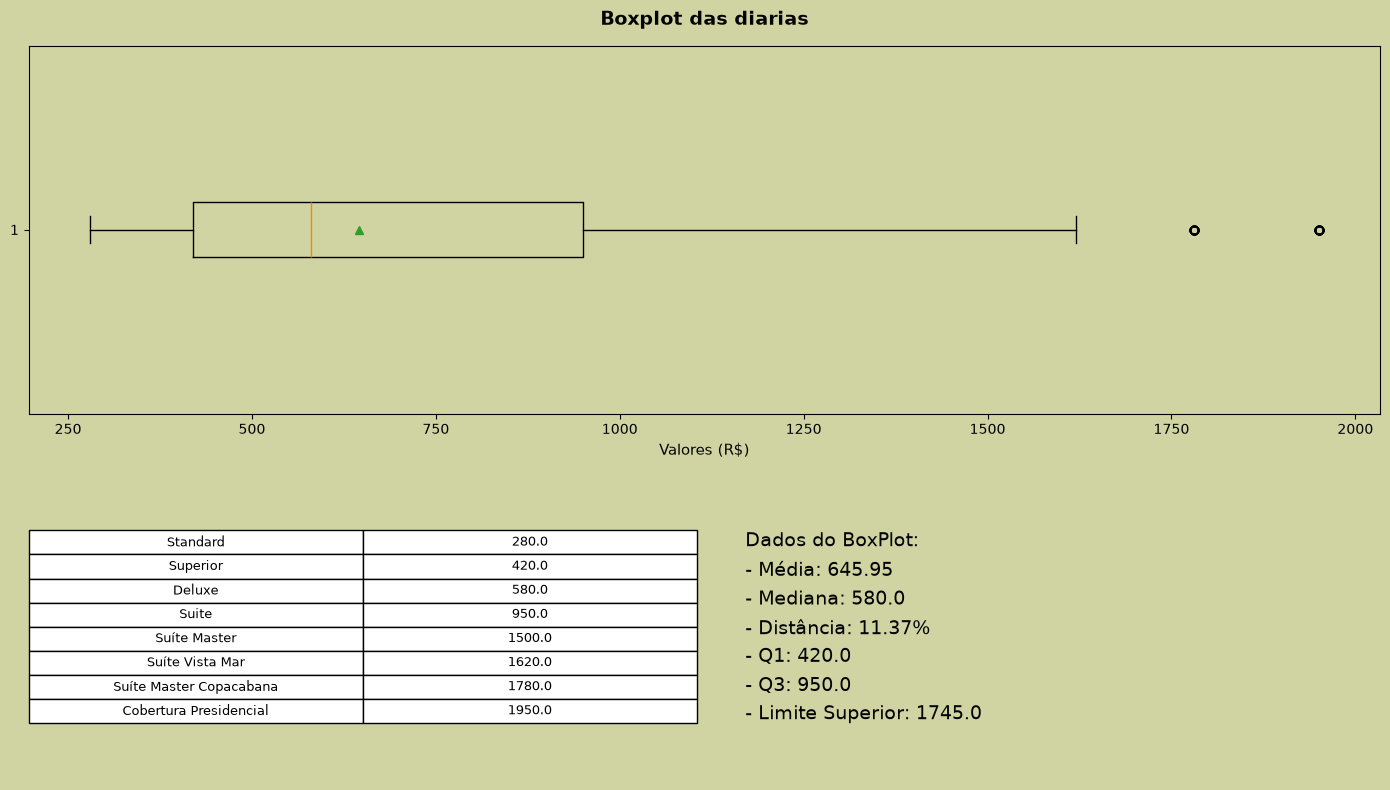

In [11]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"

# Criando a figura com GridSpec (2 linhas, 2 colunas)
fig = plt.figure(figsize=(14, 8), facecolor=cor_fundo_ppt)
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1.2, 1])

# 1. Boxplot ocupando toda a linha superior (linha 0, colunas 0 e 1)
ax_grafico = fig.add_subplot(gs[0, :])
ax_grafico.set_facecolor(cor_fundo_ppt)

ax_grafico.boxplot(array_diaria, orientation="horizontal", showmeans=True)
ax_grafico.set_title(
    "Boxplot das diarias", fontsize=14, color=cor_texto, pad=15, fontweight="bold"
)
ax_grafico.set_xlabel("Valores (R$)", fontsize=11, color=cor_texto)

# 2. Informações de Texto na coordenada inferior esquerda [1, 0]
ax_texto = fig.add_subplot(gs[1, 1])
ax_texto.set_facecolor(cor_fundo_ppt)
ax_texto.axis("off")

texto_explicativo = (
    "Dados do BoxPlot:\n"
    f"- Média: {media_diaria:.2f}\n"
    f"- Mediana: {mediana_diaria}\n"
    f"- Distância: {distancia_diaria:.2%}\n"
    f"- Q1: {q1_diaria}\n"
    f"- Q3: {q3_diaria}\n"
    f"- Limite Superior: {l_sup_med}"
)

ax_texto.text(
    0.05,
    0.5,
    texto_explicativo,
    fontsize=14,
    color=cor_texto,
    va="center",
    ha="left",
    family="sans-serif",
    linespacing=1.5,
)

ax_tabela = fig.add_subplot(gs[1, 0])
ax_tabela.set_facecolor("none")
ax_tabela.axis("off")

df_tq_plt = df_t_quartos[['descricao', 'valor_diaria_base']]
tabela = ax_tabela.table(
    cellText=df_tq_plt.values,
    loc="center",
    cellLoc="center",
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)  # Fonte um pouco menor para ajustar bem no canto inferior
tabela.scale(1, 1.2)

plt.tight_layout()
plt.show()

In [12]:
outlier_sup = df_no_cancel.loc[df_no_cancel['valor_diaria_base'] > l_sup_med]
outlier_inf = df_no_cancel.loc[df_no_cancel['valor_diaria_base'] < l_inf_med]
outlier_sup['descricao'].value_counts()

descricao
Suíte Master Copacabana    46
Cobertura Presidencial     44
Name: count, dtype: int64

In [13]:
df_unidades[['id_unidade', 'nome_unidade', 'categoria_hotel', 'num_quartos_total', 'regiao']]

,id_unidade,nome_unidade,categoria_hotel,num_quartos_total,regiao
0,1,NaraHoteis Ipanema,5 Estrelas,80,Capital
1,2,NaraHoteis Barra da Tijuca,4 Estrelas,120,Capital
2,3,NaraHoteis Centro,3 Estrelas,60,Capital
3,4,NaraHoteis Santa Teresa,4 Estrelas,45,Capital
4,5,NaraHoteis Nova Iguaçu Centro,3 Estrelas,50,Baixada Fluminense
5,6,NaraHoteis Nova Iguaçu Park,3 Estrelas,55,Baixada Fluminense
6,7,NaraHoteis Petrópolis,5 Estrelas,70,Serra
7,8,NaraHoteis Teresópolis,4 Estrelas,60,Serra
8,9,NaraHoteis Friburgo,4 Estrelas,55,Serra
9,10,NaraHoteis Paraty,5 Estrelas,75,Costa Verde


#### Faturamento por unidade:

In [14]:
df_faturamento = df_no_cancel.groupby(['id_unidade', 'nome_unidade', 'regiao'])['preco_total'].sum().reset_index().sort_values(by='preco_total', ascending=False)

In [15]:
df_faturamento

,id_unidade,nome_unidade,regiao,preco_total
11,12,NaraHoteis Mangaratiba,Costa Verde,777300.0
9,10,NaraHoteis Paraty,Costa Verde,773440.0
8,9,NaraHoteis Friburgo,Serra,744480.0
5,6,NaraHoteis Nova Iguaçu Park,Baixada Fluminense,735490.0
3,4,NaraHoteis Santa Teresa,Capital,734400.0
7,8,NaraHoteis Teresópolis,Serra,723170.0
6,7,NaraHoteis Petrópolis,Serra,700170.0
1,2,NaraHoteis Barra da Tijuca,Capital,697680.0
10,11,NaraHoteis Angra dos Reis,Costa Verde,690230.0
0,1,NaraHoteis Ipanema,Capital,688410.0


##### Quartos mais reservados nas 5 unidades com maior faturamento:

In [16]:
df_comportamento_unidade = df_no_cancel.groupby(['id_unidade', 'nome_unidade', 'descricao'])['descricao'].value_counts().reset_index()
df_unidades_5 = df_comportamento_unidade.loc[df_comportamento_unidade['id_unidade'].isin([12, 10, 9, 6, 4])].sort_values(by=['id_unidade', 'count'], ascending=[True, False])
df_top2_por_unidade = df_unidades_5.groupby('id_unidade').head(2)
df_top2_por_unidade_graf = df_top2_por_unidade[['nome_unidade', 'descricao']]
df_top2_por_unidade_graf

,nome_unidade,descricao
17,NaraHoteis Santa Teresa,Superior
14,NaraHoteis Santa Teresa,Deluxe
23,NaraHoteis Nova Iguaçu Park,Deluxe
26,NaraHoteis Nova Iguaçu Park,Superior
38,NaraHoteis Friburgo,Deluxe
41,NaraHoteis Friburgo,Superior
43,NaraHoteis Paraty,Deluxe
46,NaraHoteis Paraty,Superior
53,NaraHoteis Mangaratiba,Deluxe
54,NaraHoteis Mangaratiba,Standard


##### Medida central das avaliações da cada hotel e número de quartos, para entender o que está influênciando os dados de faturamento:

In [17]:
df_avaliac_unidade = df_no_cancel.groupby(['id_unidade', 'nome_unidade'])['avaliacao_hospede'].median().reset_index()
df_avaliac_unidade

,id_unidade,nome_unidade,avaliacao_hospede
0,1,NaraHoteis Ipanema,8.0
1,2,NaraHoteis Barra da Tijuca,7.0
2,3,NaraHoteis Centro,2.0
3,4,NaraHoteis Santa Teresa,8.0
4,5,NaraHoteis Nova Iguaçu Centro,2.0
5,6,NaraHoteis Nova Iguaçu Park,7.0
6,7,NaraHoteis Petrópolis,7.0
7,8,NaraHoteis Teresópolis,8.0
8,9,NaraHoteis Friburgo,7.0
9,10,NaraHoteis Paraty,8.0


In [18]:
df_client_uni_reser = pd.merge(df_no_cancel, df_clientes, on='id_cliente', how='inner')
df_nicho_cliente = df_client_uni_reser.groupby(['id_unidade', 'nome_unidade', 'estado_origem'])['estado_origem'].value_counts().reset_index()

In [19]:
df_nicho_cliente = df_nicho_cliente.sort_values(
    by=['id_unidade', 'count'], 
    ascending=[True, False]
)
df_nicho_unidade = df_nicho_cliente.groupby(['id_unidade', 'nome_unidade']).head(1).reset_index(drop=True)
df_nicho_unidade_graf = df_nicho_unidade[['nome_unidade', 'estado_origem']]
df_nicho_unidade_graf

,nome_unidade,estado_origem
0,NaraHoteis Ipanema,PE
1,NaraHoteis Barra da Tijuca,CE
2,NaraHoteis Centro,PE
3,NaraHoteis Santa Teresa,MG
4,NaraHoteis Nova Iguaçu Centro,CE
5,NaraHoteis Nova Iguaçu Park,PE
6,NaraHoteis Petrópolis,CE
7,NaraHoteis Teresópolis,CE
8,NaraHoteis Friburgo,PE
9,NaraHoteis Paraty,CE


correlação fazer, para entender porque o que define um faturamento alto 

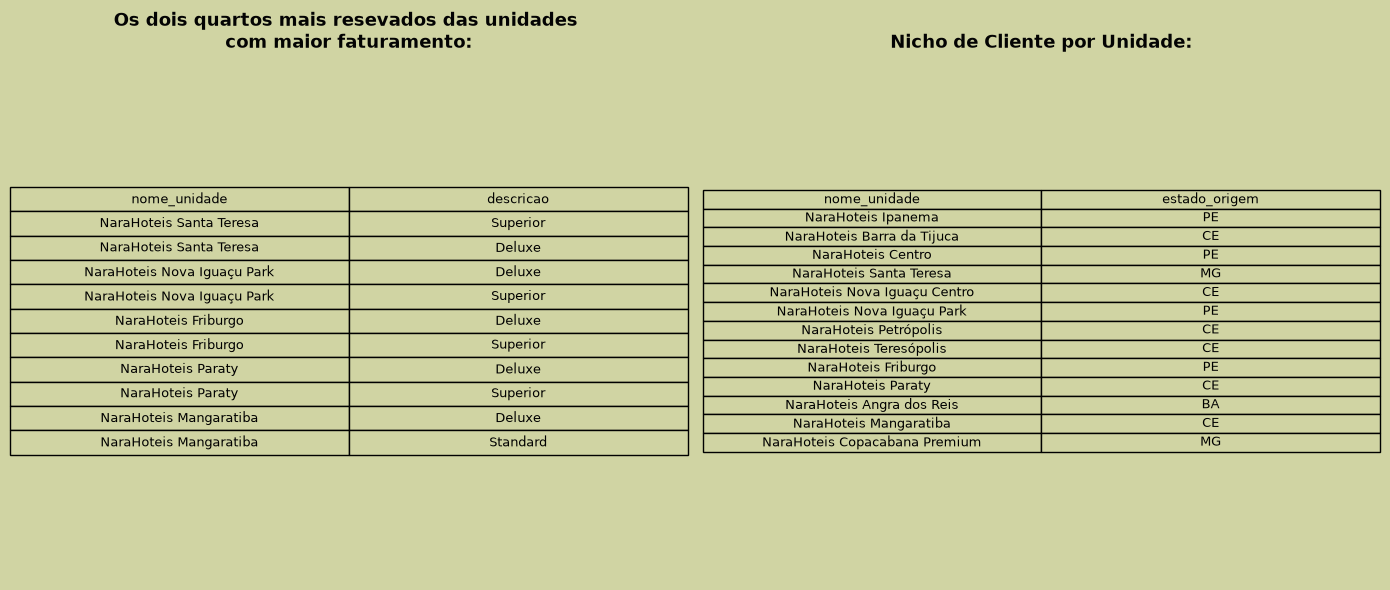

In [20]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor=cor_fundo_ppt)

# --- Subplot 1: DataFrame de Top 2 Quartos ---
ax1.set_facecolor(cor_fundo_ppt)
ax1.axis('off')
tabela1 = ax1.table(
    cellText=df_top2_por_unidade_graf.values,
    colLabels=df_top2_por_unidade_graf.columns,
    loc='center',
    cellLoc='center'
)
tabela1.auto_set_font_size(False)
tabela1.set_fontsize(9)
tabela1.scale(1, 1.3)

# Removendo o fundo branco das células da tabela 1
for key, cell in tabela1.get_celld().items():
    cell.set_facecolor(cor_fundo_ppt)

ax1.set_title("Os dois quartos mais resevados das unidades \ncom maior faturamento:", fontsize=13, color=cor_texto, fontweight="bold", pad=10)

# --- Subplot 2: DataFrame de Nicho de Cliente ---
ax2.set_facecolor(cor_fundo_ppt)
ax2.axis('off')
tabela2 = ax2.table(
    cellText=df_nicho_unidade_graf.values,
    colLabels=df_nicho_unidade_graf.columns,
    loc='center',
    cellLoc='center'
)
tabela2.auto_set_font_size(False)
tabela2.set_fontsize(9)
tabela2.scale(1, 1)

# Removendo o fundo branco das células da tabela 2
for key, cell in tabela2.get_celld().items():
    cell.set_facecolor(cor_fundo_ppt)

ax2.set_title("Nicho de Cliente por Unidade:", fontsize=13, color=cor_texto, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

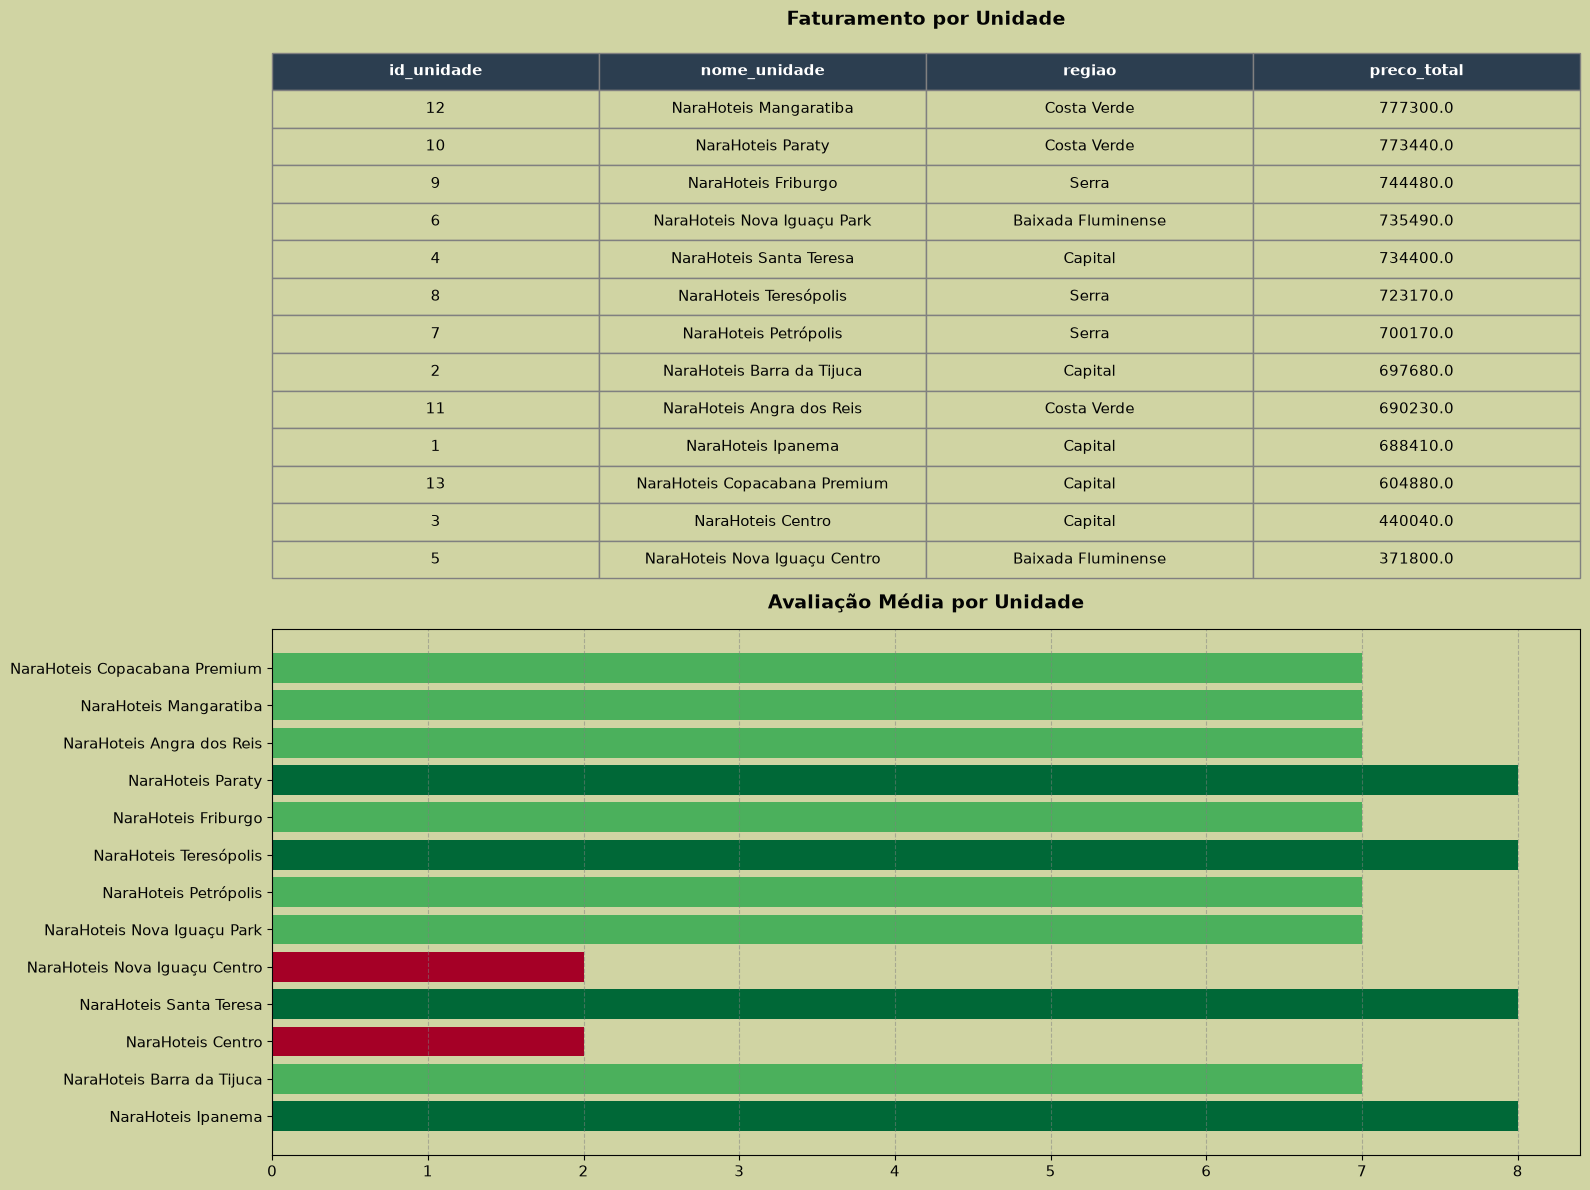

In [21]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# Criando a figura com 2 linhas e 1 coluna (empilhados)
fig, (ax_tabela, ax_grafico) = plt.subplots(2, 1, figsize=(16, 12), facecolor=cor_fundo_ppt)

# Definindo a cor de fundo dos eixos
ax_tabela.set_facecolor(cor_fundo_ppt)
ax_grafico.set_facecolor(cor_fundo_ppt)

# --- Linha 1: df_faturamento como Tabela ---
ax_tabela.axis("off")

# Criando a tabela
tabela = ax_tabela.table(
    cellText=df_faturamento.values,
    colLabels=df_faturamento.columns,
    loc='center',
    cellLoc='center'
)

# Estilizando a tabela para combinar com o tema e ter mais espaço
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1, 1.8)  # Aumenta o espaçamento interno das células

for key, cell in tabela.get_celld().items():
    cell.set_text_props(color=cor_texto)
    cell.set_edgecolor('gray')
    if key[0] == 0:  # Cabeçalho da tabela
        cell.set_facecolor(minhas_cores[0])
        cell.set_text_props(color='white', fontweight='bold')
    else:  # Células de dados
        cell.set_facecolor(cor_fundo_ppt)

ax_tabela.set_title("Faturamento por Unidade", fontsize=14, color=cor_texto, fontweight="bold", pad=20)

# --- Linha 2: Gráfico de Avaliação Média (Cores de verde a vermelho) ---
norm = plt.Normalize(df_avaliac_unidade['avaliacao_hospede'].min(), df_avaliac_unidade['avaliacao_hospede'].max())
cmap = plt.get_cmap('RdYlGn')
cores_barras = [cmap(norm(val)) for val in df_avaliac_unidade['avaliacao_hospede']]

bars = ax_grafico.barh(
    df_avaliac_unidade['nome_unidade'], 
    df_avaliac_unidade['avaliacao_hospede'], 
    color=cores_barras
)
ax_grafico.set_title("Avaliação Média por Unidade", fontsize=14, color=cor_texto, fontweight="bold", pad=15)
ax_grafico.tick_params(colors=cor_texto, labelsize=11)
ax_grafico.grid(axis='x', linestyle='--', alpha=0.5, color='gray')

# Ajustando as bordas do gráfico para o tema
for spine in ax_grafico.spines.values():
    spine.set_color(cor_texto)

# Ajuste final de layout para evitar cortes
plt.tight_layout()
plt.show()

## Pergunta 2

In [22]:
df_noshow = pd.read_csv('../../dados/extra/sqloverbookingNS.csv', sep=',')
df_semns = pd.read_csv('../../dados/extra/sqloverbooking.csv', sep=',')

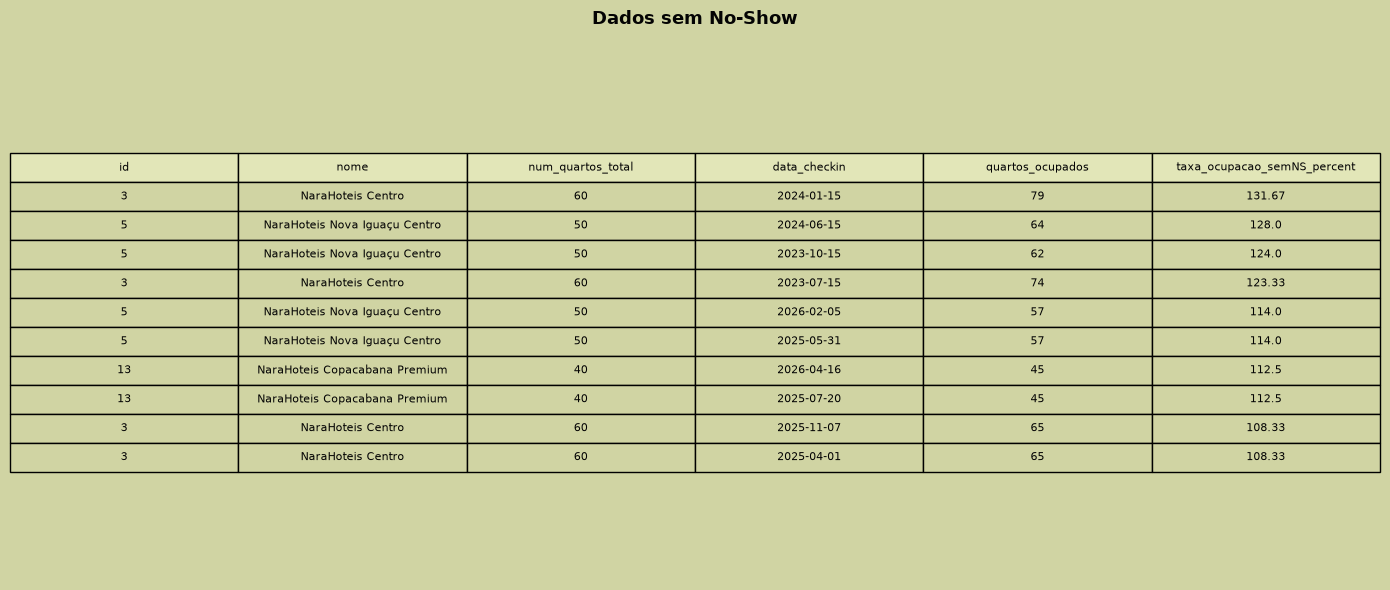

In [23]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"

# Aumentamos a largura da figura para acomodar melhor todas as colunas
fig, ax = plt.subplots(figsize=(14, 6), facecolor=cor_fundo_ppt)

ax.set_facecolor(cor_fundo_ppt)
ax.axis("off")

tabela = ax.table(
    cellText=df_semns.values,
    colLabels=df_semns.columns,
    loc="center",
    cellLoc="center"
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(8)  # Fonte reduzida para evitar sobreposição nas colunas
tabela.scale(1, 1.5)    # Ajusta o espaçamento vertical das linhas

for key, cell in tabela.get_celld().items():
    cell.set_text_props(color=cor_texto)
    cell.set_facecolor('#E2E6B8FF' if key[0] == 0 else cor_fundo_ppt)

ax.set_title("Dados sem No-Show", fontsize=13, color=cor_texto, fontweight="bold", pad=15)

plt.tight_layout()
plt.show()

## Pergunta 3

O ticket medio com certeza geraria um outlier já que os quartos de certas unidades são mais caros por natureza, então o faturamento é a melhor forma de mostrar a performace da receita das unidade

In [24]:
array_faturamento = np.array(df_faturamento['preco_total'])

In [25]:
media_fat = np.mean(array_faturamento)
mediana_fat = np.median(array_faturamento)
q1_fat = np.percentile(array_faturamento, 25)
q3_fat = np.percentile(array_faturamento, 75)
distancia = (media_fat - mediana_fat) / mediana_fat

print(f'Media: {round(media_fat, 2)} \nMediana: {mediana_fat} \nDistancia: {round(distancia, 2)}')
print(f'Q1: {q1_fat} Q3: {q3_fat}')

Media: 667806.92 
Mediana: 700170.0 
Distancia: -0.05
Q1: 688410.0 Q3: 735490.0


In [26]:
iqr_fat = q3_fat - q1_fat
l_sup_fat = q3_fat + (iqr_fat*1.5)
l_inf_fat = q1_fat - (iqr_fat*1.5)
print(l_sup_fat, l_inf_fat)

806110.0 617790.0


In [27]:
outliers_inf_fat = df_faturamento[['nome_unidade', 'regiao', 'preco_total']].loc[df_faturamento['preco_total'] < l_inf_fat]
outliers_inf_fat

,nome_unidade,regiao,preco_total
12,NaraHoteis Copacabana Premium,Capital,604880.0
2,NaraHoteis Centro,Capital,440040.0
4,NaraHoteis Nova Iguaçu Centro,Baixada Fluminense,371800.0


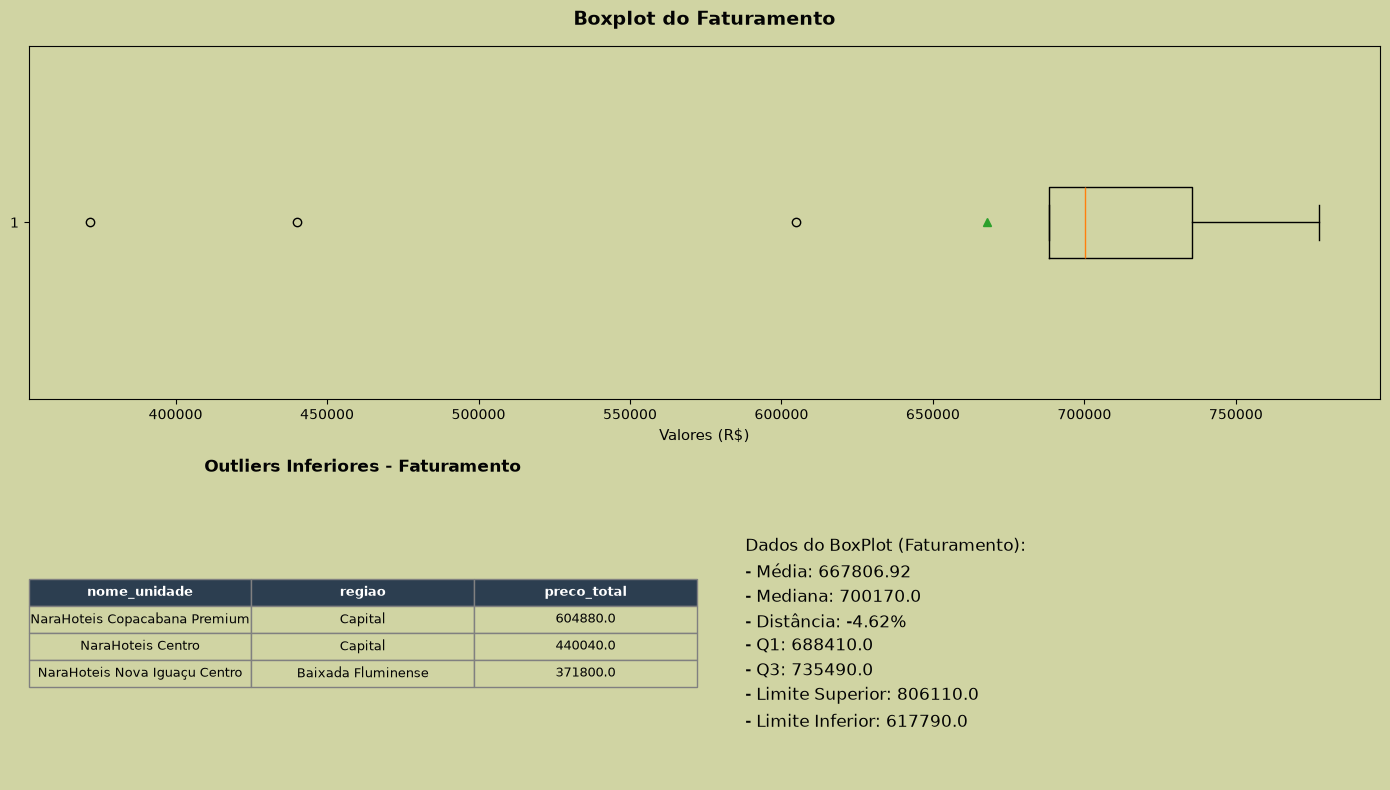

In [28]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# Criando a figura com GridSpec (2 linhas, 2 colunas)
fig = plt.figure(figsize=(14, 8), facecolor=cor_fundo_ppt)
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1.2, 1])

# 1. Boxplot ocupando toda a linha superior com os dados de faturamento
ax_grafico = fig.add_subplot(gs[0, :])
ax_grafico.set_facecolor(cor_fundo_ppt)

ax_grafico.boxplot(array_faturamento, orientation="horizontal", showmeans=True, widths=0.2)
ax_grafico.set_title(
    "Boxplot do Faturamento", fontsize=14, color=cor_texto, pad=15, fontweight="bold"
)
ax_grafico.set_xlabel("Valores (R$)", fontsize=11, color=cor_texto)

# Ajustando as bordas e ticks do boxplot para o tema
ax_grafico.tick_params(colors=cor_texto, labelsize=10)
for spine in ax_grafico.spines.values():
    spine.set_color(cor_texto)

# 2. Informações de Texto estatísticas na coordenada inferior direita [1, 1]
ax_texto = fig.add_subplot(gs[1, 1])
ax_texto.set_facecolor(cor_fundo_ppt)
ax_texto.axis("off")

texto_explicativo = (
    "Dados do BoxPlot (Faturamento):\n"
    f"- Média: {media_fat:.2f}\n"
    f"- Mediana: {mediana_fat}\n"
    f"- Distância: {distancia:.2%}\n"
    f"- Q1: {q1_fat}\n"
    f"- Q3: {q3_fat}\n"
    f"- Limite Superior: {l_sup_fat}\n"
    f"- Limite Inferior: {l_inf_fat}"
)

ax_texto.text(
    0.05,
    0.5,
    texto_explicativo,
    fontsize=12,
    color=cor_texto,
    va="center",
    ha="left",
    family="sans-serif",
    linespacing=1.5,
)

# 3. Adicionando o df de outliers_inf_fat na coordenada inferior esquerda [1, 0]
ax_tabela = fig.add_subplot(gs[1, 0])
ax_tabela.set_facecolor(cor_fundo_ppt)
ax_tabela.axis("off")

tabela = ax_tabela.table(
    cellText=outliers_inf_fat.values,
    colLabels=outliers_inf_fat.columns,
    loc='center',
    cellLoc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1, 1.4)

for key, cell in tabela.get_celld().items():
    cell.set_text_props(color=cor_texto)
    cell.set_edgecolor('gray')
    if key[0] == 0:  # Cabeçalho da tabela
        cell.set_facecolor(minhas_cores[0])
        cell.set_text_props(color='white', fontweight='bold')
    else:  # Células de dados
        cell.set_facecolor(cor_fundo_ppt)

ax_tabela.set_title("Outliers Inferiores - Faturamento", fontsize=12, color=cor_texto, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

## Pergunta 4:

Primeira parte, recortando 2 periodos diferentes

Recorte total, desde o lançamento de cada unidade:

In [29]:
# Average Daily Rate, resumindo valor medio das diarias
df_adr = df_no_cancel.groupby(['id_unidade', 'nome_unidade', 'num_quartos_total'])['valor_diaria_base'].mean().reset_index(name='adr')

In [30]:
df_diarias_vendidas = df_no_cancel.groupby('id_unidade')['qtd_diarias'].sum().reset_index(name='diarias_vendidas')

df_dias_unidade = df_no_cancel.groupby('id_unidade').agg(
    min_checkin=('data_checkin', 'min'),
    max_checkout=('data_checkout', 'max')
).reset_index()
# .days para extrair apenas o número inteiro do Deltatime, subtração de data
# Resumindo esse valor é a quantidade de diarias disponiveis 
df_dias_unidade['dias_operacao'] = (df_dias_unidade['max_checkout'] - df_dias_unidade['min_checkin']).dt.days

df_revpar = pd.merge(df_adr, df_diarias_vendidas, on='id_unidade')

# Total de quartos disponíveis no período histórico
df_revpar['quartos_disponiveis_total'] = df_revpar['num_quartos_total'] * df_dias_unidade['dias_operacao']

# Taxa de Ocupação (% das diárias vendidas sobre a capacidade total do período), sem porcentagem para o calculo 
df_revpar['taxa_ocupacao'] = (df_revpar['diarias_vendidas'] / df_revpar['quartos_disponiveis_total']) 

In [31]:
df_revpar['media_revpar'] = df_revpar['adr'] * df_revpar['taxa_ocupacao']
df_revpar['faturamento_revpar'] = df_faturamento['preco_total'] / df_revpar['quartos_disponiveis_total']

In [32]:
df_revpar['avaliacao_media'] = df_avaliac_unidade['avaliacao_hospede']

In [33]:
# Formatações
df_revpar['taxa_ocupacao'] = round((df_revpar['diarias_vendidas'] / df_revpar['quartos_disponiveis_total']) * 100, 2)
df_revpar['adr'] = round(df_revpar['adr'], 2)
df_revpar['media_revpar'] = round(df_revpar['media_revpar'], 2)
df_revpar['faturamento_revpar'] = round(df_revpar['faturamento_revpar'], 2)

In [34]:
df_revpar_graf = df_revpar[['nome_unidade', 'num_quartos_total', 'adr', 'diarias_vendidas', 'quartos_disponiveis_total', 'taxa_ocupacao', 'media_revpar', 'avaliacao_media', 'faturamento_revpar']].sort_values(by='faturamento_revpar', ascending=False)
df_revpar_graf

,nome_unidade,num_quartos_total,adr,diarias_vendidas,quartos_disponiveis_total,taxa_ocupacao,media_revpar,avaliacao_media,faturamento_revpar
12,NaraHoteis Copacabana Premium,40,1803.87,335,23600,1.42,25.61,7.0,25.63
3,NaraHoteis Santa Teresa,45,626.97,1181,60030,1.97,12.33,8.0,12.23
11,NaraHoteis Mangaratiba,50,685.21,1152,66900,1.72,11.80,7.0,11.62
8,NaraHoteis Friburgo,55,672.49,1111,73590,1.51,10.15,7.0,10.12
5,NaraHoteis Nova Iguaçu Park,55,694.59,1053,72930,1.44,10.03,7.0,10.08
7,NaraHoteis Teresópolis,60,678.09,1057,80340,1.32,8.92,8.0,9.00
9,NaraHoteis Paraty,75,705.86,1122,100500,1.12,7.88,8.0,7.70
6,NaraHoteis Petrópolis,70,638.54,1078,93660,1.15,7.35,7.0,7.48
0,NaraHoteis Ipanema,80,650.19,1095,106160,1.03,6.71,8.0,6.48
10,NaraHoteis Angra dos Reis,90,679.79,1006,119520,0.84,5.72,7.0,5.78


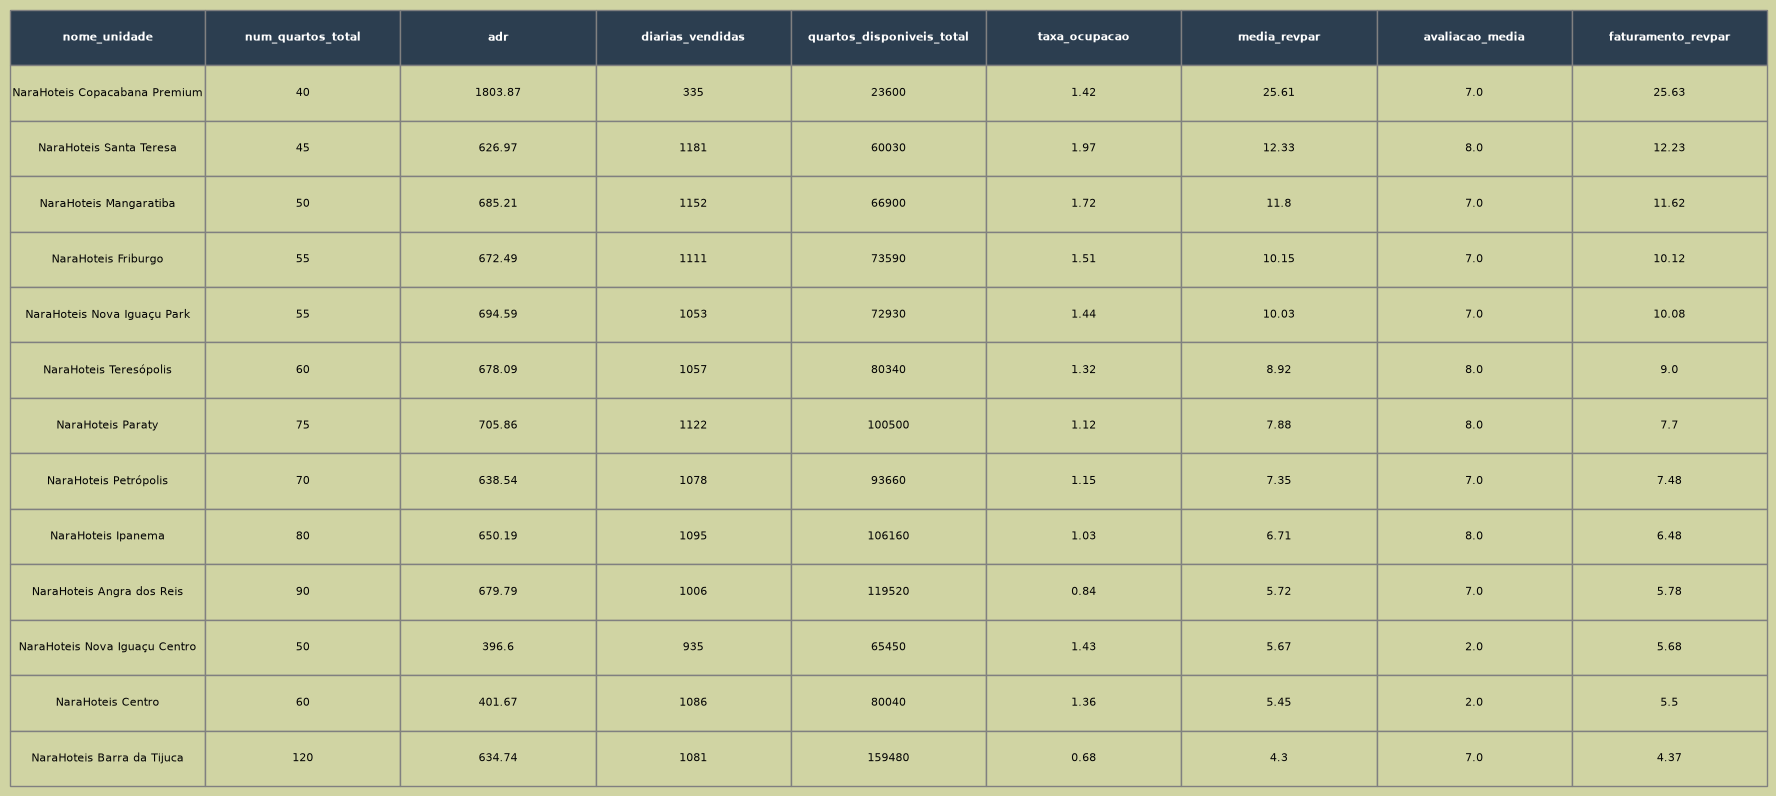

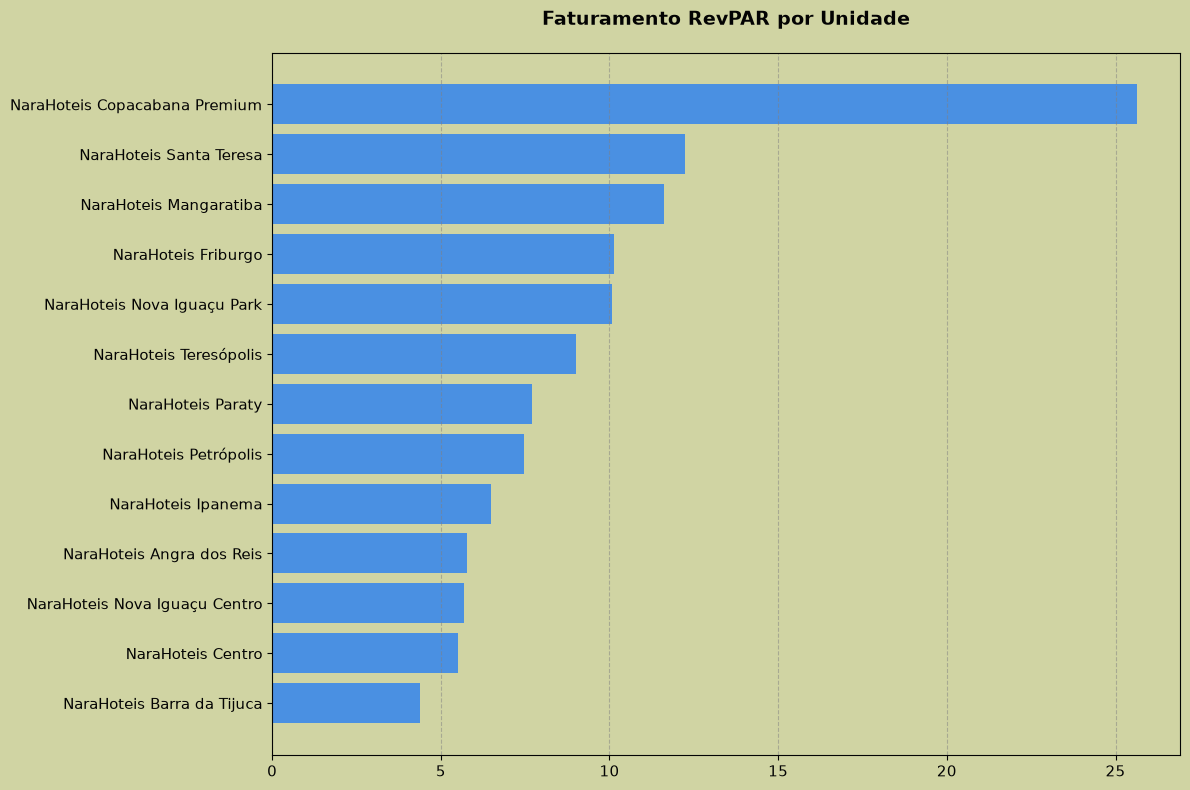

In [35]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# ==========================================
# 1. FIGURA DA TABELA
# ==========================================
fig_tabela, ax_tabela = plt.subplots(figsize=(18, 8), facecolor=cor_fundo_ppt)
ax_tabela.set_facecolor(cor_fundo_ppt)
ax_tabela.axis("off")

# Usando o bbox ajustado para a tabela expandida ([esquerda, embaixo, largura, altura])
tabela = ax_tabela.table(
    cellText=df_revpar_graf.values,
    colLabels=df_revpar_graf.columns,
    cellLoc='center',
    bbox=[-0.15, -0.1, 1.3, 1.2]
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)

for key, cell in tabela.get_celld().items():
    cell.set_text_props(color=cor_texto)
    cell.set_edgecolor('gray')
    if key[0] == 0:  # Cabeçalho da tabela
        cell.set_facecolor(minhas_cores[0])
        cell.set_text_props(color='white', fontweight='bold')
    else:  # Células de dados
        cell.set_facecolor(cor_fundo_ppt)

plt.tight_layout()
plt.savefig('tabelarevpar.png', dpi=300, facecolor=fig_tabela.get_facecolor(), edgecolor='none')
plt.show()
plt.close(fig_tabela)


# ==========================================
# 2. FIGURA DO GRÁFICO DE BARRAS
# ==========================================
fig_grafico, ax_grafico = plt.subplots(figsize=(12, 8), facecolor=cor_fundo_ppt)
ax_grafico.set_facecolor(cor_fundo_ppt)

coluna_categorias = 'nome_unidade' if 'nome_unidade' in df_revpar_graf.columns else df_revpar_graf.columns[0]

bars = ax_grafico.barh(
    df_revpar_graf[coluna_categorias], 
    df_revpar_graf['faturamento_revpar'], 
    color=minhas_cores[2]
)

ax_grafico.invert_yaxis()
ax_grafico.set_title("Faturamento RevPAR por Unidade", fontsize=14, color=cor_texto, fontweight="bold", pad=20)
ax_grafico.tick_params(colors=cor_texto, labelsize=11)
ax_grafico.grid(axis='x', linestyle='--', alpha=0.5, color='gray')

# Ajustando as bordas do gráfico para o tema
for spine in ax_grafico.spines.values():
    spine.set_color(cor_texto)

plt.tight_layout()
plt.savefig('../../graficos/graficorevpar.png', dpi=300, facecolor=fig_grafico.get_facecolor(), edgecolor='none')
plt.show()
plt.close(fig_grafico)

Recorte do primeiro semestre de 2026:

In [36]:
# Preparando 
df_semestre = df_no_cancel.loc[(df_no_cancel['data_checkin'] >= '2026-01-01') & (df_no_cancel['data_checkin'] <= '2026-06-30')]
# Total de dias fixo do semestre 
dias_semestre = 181
# Agrupamento das metricas
df_revpar_semestre26= df_semestre.groupby(['id_unidade', 'nome_unidade']).agg(
    faturamento=('preco_total', 'sum'),
    diarias_vendidas=('qtd_diarias', 'sum')
).reset_index()

In [37]:
# Juntando os dados
df_revpar_semestre26 = pd.merge(df_revpar_semestre26, df_unidades[['id_unidade', 'num_quartos_total']], on='id_unidade')

In [38]:
# Organizando
df_revpar_semestre26['adr'] = (df_revpar_semestre26['faturamento'] / df_revpar_semestre26['diarias_vendidas']).round(2)
df_revpar_semestre26['quartos_disponiveis_total'] = df_revpar_semestre26['num_quartos_total'] * dias_semestre
df_revpar_semestre26['taxa_ocupacao_%'] = ((df_revpar_semestre26['diarias_vendidas'] / df_revpar_semestre26['quartos_disponiveis_total']) * 100).round(2)
df_revpar_semestre26['revpar'] = (df_revpar_semestre26['faturamento'] / df_revpar_semestre26['quartos_disponiveis_total']).round(2)

In [39]:
df_avaliac26 = df_semestre.groupby(['id_unidade', 'nome_unidade'])['avaliacao_hospede'].median().reset_index()
df_revpar_semestre26['avaliacao_media'] = df_avaliac26['avaliacao_hospede']

In [40]:
# Ordenação e display
df_revpar_26_graf = df_revpar_semestre26[['nome_unidade', 'num_quartos_total', 'adr', 'diarias_vendidas', 'quartos_disponiveis_total', 'taxa_ocupacao_%', 'avaliacao_media', 'revpar']].sort_values(by='revpar', ascending=False)
df_revpar_26_graf

,nome_unidade,num_quartos_total,adr,diarias_vendidas,quartos_disponiveis_total,taxa_ocupacao_%,avaliacao_media,revpar
12,NaraHoteis Copacabana Premium,40,1805.63,151,7240,2.09,7.0,37.66
11,NaraHoteis Mangaratiba,50,784.26,162,9050,1.79,7.0,14.04
3,NaraHoteis Santa Teresa,45,705.65,138,8145,1.69,8.0,11.96
8,NaraHoteis Friburgo,55,773.86,140,9955,1.41,7.0,10.88
4,NaraHoteis Nova Iguaçu Centro,50,417.65,230,9050,2.54,2.0,10.61
7,NaraHoteis Teresópolis,60,803.16,114,10860,1.05,8.0,8.43
6,NaraHoteis Petrópolis,70,715.87,138,12670,1.09,7.0,7.80
5,NaraHoteis Nova Iguaçu Park,55,750.00,98,9955,0.98,7.0,7.38
9,NaraHoteis Paraty,75,715.74,136,13575,1.00,8.0,7.17
0,NaraHoteis Ipanema,80,671.99,141,14480,0.97,7.5,6.54


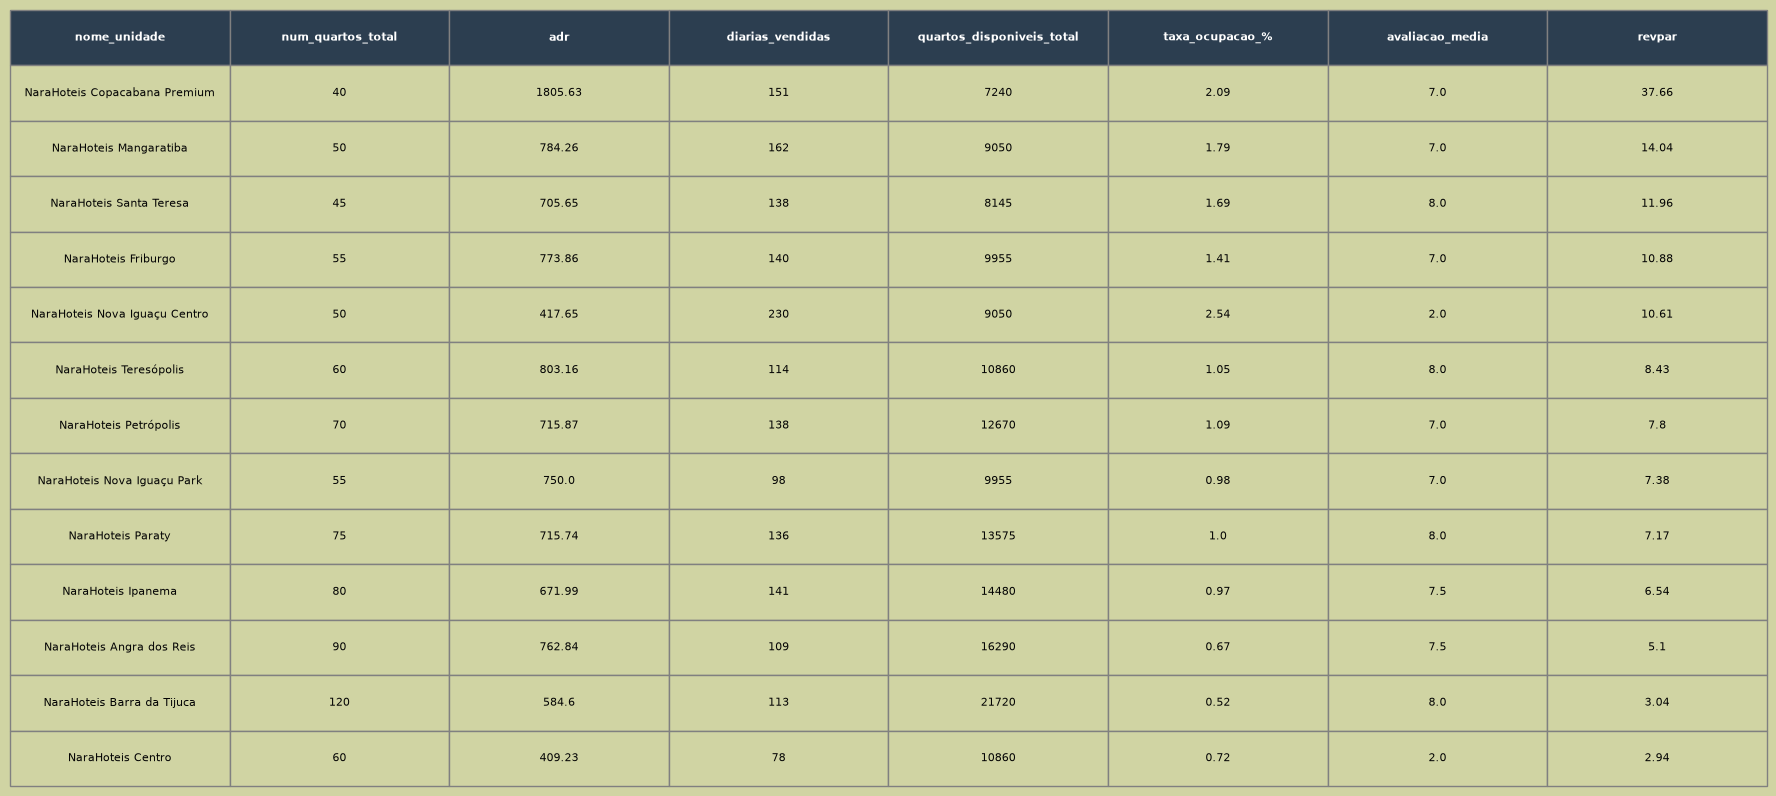

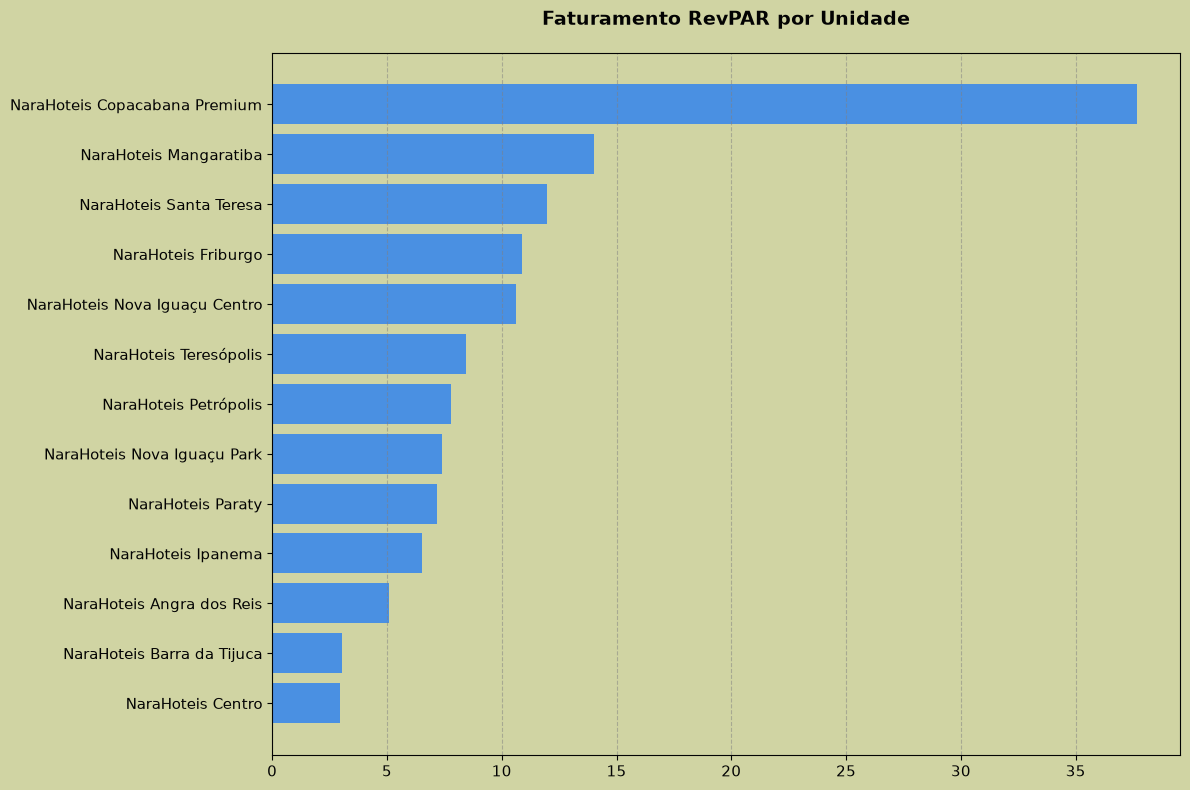

In [41]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# ==========================================
# 1. FIGURA DA TABELA
# ==========================================
fig_tabela, ax_tabela = plt.subplots(figsize=(18, 8), facecolor=cor_fundo_ppt)
ax_tabela.set_facecolor(cor_fundo_ppt)
ax_tabela.axis("off")

# Usando o bbox ajustado para a tabela expandida ([esquerda, embaixo, largura, altura])
tabela = ax_tabela.table(
    cellText=df_revpar_26_graf.values,
    colLabels=df_revpar_26_graf.columns,
    cellLoc='center',
    bbox=[-0.15, -0.1, 1.3, 1.2]
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)

for key, cell in tabela.get_celld().items():
    cell.set_text_props(color=cor_texto)
    cell.set_edgecolor('gray')
    if key[0] == 0:  # Cabeçalho da tabela
        cell.set_facecolor(minhas_cores[0])
        cell.set_text_props(color='white', fontweight='bold')
    else:  # Células de dados
        cell.set_facecolor(cor_fundo_ppt)

plt.tight_layout()
plt.savefig('tabelarevpar26.png', dpi=300, facecolor=fig_tabela.get_facecolor(), edgecolor='none')
plt.show()
plt.close(fig_tabela)


# ==========================================
# 2. FIGURA DO GRÁFICO DE BARRAS
# ==========================================
fig_grafico, ax_grafico = plt.subplots(figsize=(12, 8), facecolor=cor_fundo_ppt)
ax_grafico.set_facecolor(cor_fundo_ppt)

coluna_categorias = 'nome_unidade' if 'nome_unidade' in df_revpar_26_graf.columns else df_revpar_26_graf.columns[0]

bars = ax_grafico.barh(
    df_revpar_26_graf[coluna_categorias], 
    df_revpar_26_graf['revpar'], 
    color=minhas_cores[2]
)

ax_grafico.invert_yaxis()
ax_grafico.set_title("Faturamento RevPAR por Unidade", fontsize=14, color=cor_texto, fontweight="bold", pad=20)
ax_grafico.tick_params(colors=cor_texto, labelsize=11)
ax_grafico.grid(axis='x', linestyle='--', alpha=0.5, color='gray')

# Ajustando as bordas do gráfico para o tema
for spine in ax_grafico.spines.values():
    spine.set_color(cor_texto)

plt.tight_layout()
plt.savefig('../../graficos/graficorevpar26.png', dpi=300, facecolor=fig_grafico.get_facecolor(), edgecolor='none')
plt.show()
plt.close(fig_grafico)

Correlecação entre avaliação e RevPAR

Correlação total:

In [42]:
array_revpar = np.array(df_revpar['faturamento_revpar'])
array_avaliac = np.array(df_revpar['avaliacao_media'])

<Axes: >

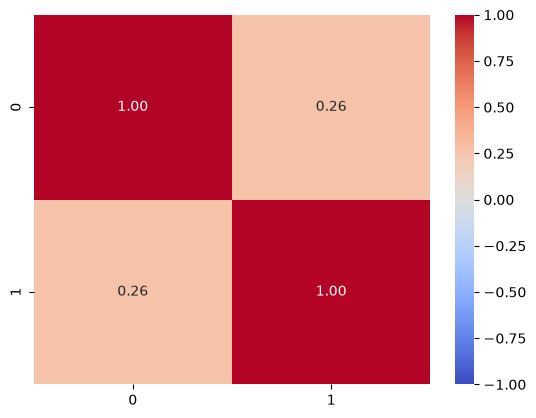

In [43]:
c_rev_avaliac = np.corrcoef(array_revpar, array_avaliac)
sns.heatmap(c_rev_avaliac, 
            annot=True,
            cmap='coolwarm', 
            vmin=-1,
            vmax=1,
            fmt='.2f'
            )

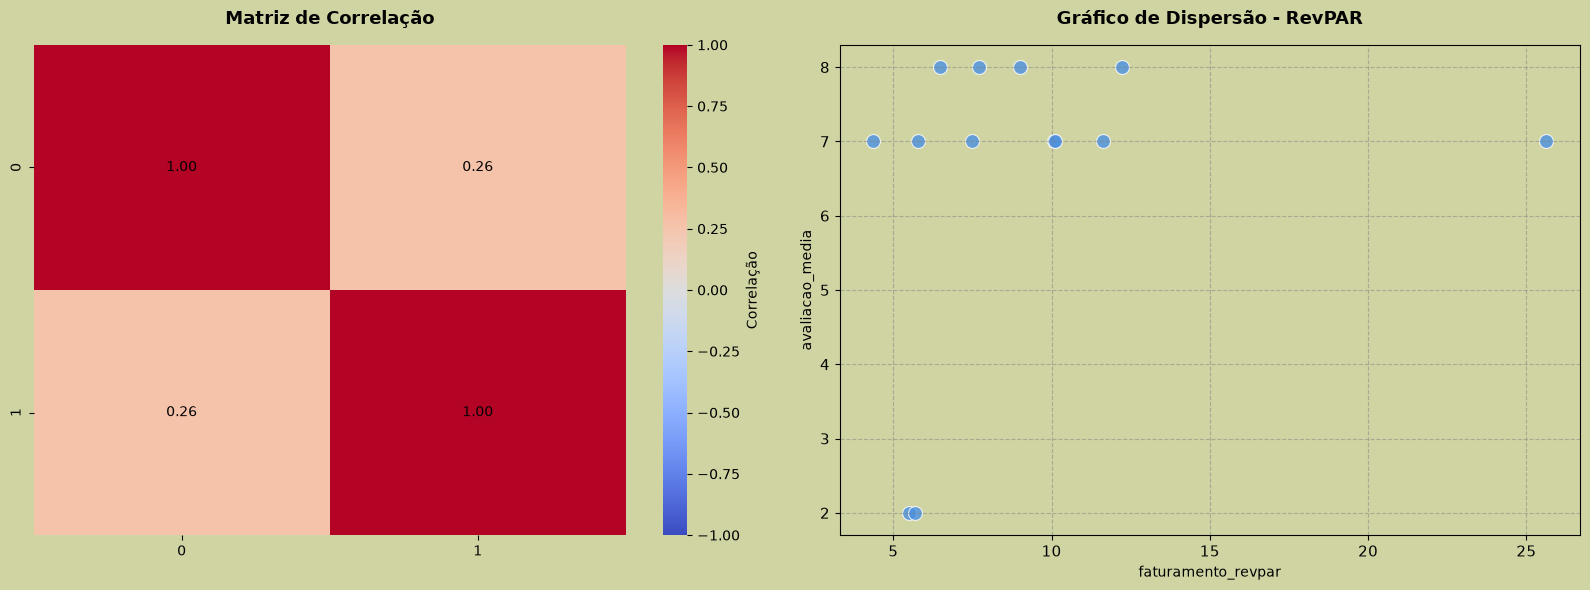

In [44]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# Criando a figura com 1 linha e 2 colunas lado a lado
fig, (ax_heatmap, ax_scatter) = plt.subplots(1, 2, figsize=(16, 6), facecolor=cor_fundo_ppt)

# Definindo a cor de fundo dos eixos
ax_heatmap.set_facecolor(cor_fundo_ppt)
ax_scatter.set_facecolor(cor_fundo_ppt)

# --- Coluna 1: Heatmap ---
sns.heatmap(
    c_rev_avaliac, 
    annot=True,
    cmap='coolwarm', 
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=ax_heatmap,
    cbar_kws={'label': 'Correlação'}
)

ax_heatmap.set_title("Matriz de Correlação", fontsize=13, color=cor_texto, fontweight="bold", pad=15)
ax_heatmap.tick_params(colors=cor_texto)

# Ajustando a cor dos textos internos do heatmap para combinar com o tema
for text in ax_heatmap.texts:
    text.set_color(cor_texto)

# --- Coluna 2: Gráfico Scatter (Dispersão) ---
# ATENÇÃO: Substitua 'coluna_x' e 'coluna_y' pelos nomes reais das colunas do seu df_revpar_semestre26
coluna_x = 'faturamento_revpar' 
coluna_y = 'avaliacao_media'

sns.scatterplot(
    data=df_revpar,
    x=coluna_x,
    y=coluna_y,
    ax=ax_scatter,
    color=minhas_cores[2],  # Usando a cor do seu tema
    s=100,
    alpha=0.8
)

ax_scatter.set_title("Gráfico de Dispersão - RevPAR", fontsize=13, color=cor_texto, fontweight="bold", pad=15)
ax_scatter.tick_params(colors=cor_texto, labelsize=11)
ax_scatter.grid(axis='both', linestyle='--', alpha=0.5, color='gray')

# Ajustando as bordas do gráfico para o tema
for spine in ax_scatter.spines.values():
    spine.set_color(cor_texto)

# Ajuste final de layout
plt.tight_layout()
plt.show()

Correlação do semestre de 26:

In [45]:
array_revpar26 = np.array(df_revpar_semestre26['revpar'])
array_avaliac26 = np.array(df_revpar_semestre26['avaliacao_media'])

In [46]:
c_rev_avaliac26 = np.corrcoef(array_revpar26, array_avaliac26)

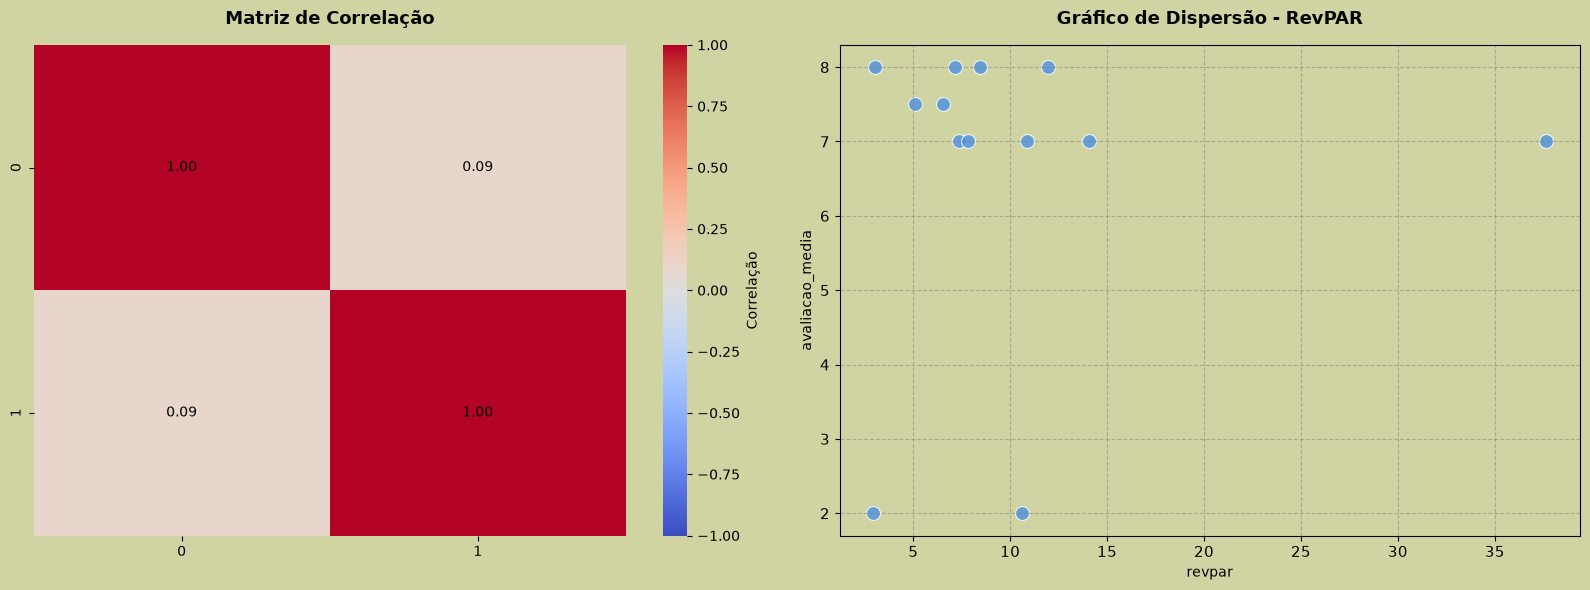

In [47]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# Criando a figura com 1 linha e 2 colunas lado a lado
fig, (ax_heatmap, ax_scatter) = plt.subplots(1, 2, figsize=(16, 6), facecolor=cor_fundo_ppt)

# Definindo a cor de fundo dos eixos
ax_heatmap.set_facecolor(cor_fundo_ppt)
ax_scatter.set_facecolor(cor_fundo_ppt)

# --- Coluna 1: Heatmap ---
sns.heatmap(
    c_rev_avaliac26, 
    annot=True,
    cmap='coolwarm', 
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=ax_heatmap,
    cbar_kws={'label': 'Correlação'}
)

ax_heatmap.set_title("Matriz de Correlação", fontsize=13, color=cor_texto, fontweight="bold", pad=15)
ax_heatmap.tick_params(colors=cor_texto)

# Ajustando a cor dos textos internos do heatmap para combinar com o tema
for text in ax_heatmap.texts:
    text.set_color(cor_texto)

# --- Coluna 2: Gráfico Scatter (Dispersão) ---
# ATENÇÃO: Substitua 'coluna_x' e 'coluna_y' pelos nomes reais das colunas do seu df_revpar_semestre26
coluna_x = 'revpar' 
coluna_y = 'avaliacao_media'

sns.scatterplot(
    data=df_revpar_semestre26,
    x=coluna_x,
    y=coluna_y,
    ax=ax_scatter,
    color=minhas_cores[2],  # Usando a cor do seu tema
    s=100,
    alpha=0.8
)

ax_scatter.set_title("Gráfico de Dispersão - RevPAR", fontsize=13, color=cor_texto, fontweight="bold", pad=15)
ax_scatter.tick_params(colors=cor_texto, labelsize=11)
ax_scatter.grid(axis='both', linestyle='--', alpha=0.5, color='gray')

# Ajustando as bordas do gráfico para o tema
for spine in ax_scatter.spines.values():
    spine.set_color(cor_texto)

# Ajuste final de layout
plt.tight_layout()
plt.show()

Pergunta 5: Uma analise não é possível porque a correlação entre avaliação e revpar é baixa, construir um modelo abriria margens altas de erro

## Pergunta 6:

Geral:

In [48]:
variancia_fat = np.var(array_faturamento)
std_fat = np.std(array_faturamento)
print(f'Variancia: {variancia_fat:.2f} \nSTD: {std_fat:.2f}')
print(f"Faixa típica: {media_fat-std_fat:.2f} até {media_fat+std_fat:.2f}")

Variancia: 14417789744.38 
STD: 120074.10
Faixa típica: 547732.82 até 787881.02


In [49]:
df_unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 Estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 Estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 Estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 Estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 Estrelas,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,75


Função assim eu não fico repetindo o codigo:

In [50]:
def derivacao_regiao(regiao):
    df_regiao = df_faturamento.loc[df_faturamento['regiao'] == regiao]
    array = np.array(df_regiao['preco_total'])
    media = np.mean(array)
    variancia = np.var(array)
    std = np.std(array)
    menor_val = media-std
    maior_val = media+std
    print(f'Variancia: {variancia:.2f} \nSTD: {std:.2f}')
    print(f"Faixa típica: {menor_val:.2f} até {maior_val:.2f}")
    return {'df': df_regiao, 'media': media, 'variancia': variancia, 'std': std, 'menor': menor_val, 'maior': maior_val}

capital:

In [51]:
capital = derivacao_regiao('Capital')

Variancia: 11111998576.00 
STD: 105413.46
Faixa típica: 527668.54 até 738495.46


In [52]:
capital['df']

,id_unidade,nome_unidade,regiao,preco_total
3,4,NaraHoteis Santa Teresa,Capital,734400.0
1,2,NaraHoteis Barra da Tijuca,Capital,697680.0
0,1,NaraHoteis Ipanema,Capital,688410.0
12,13,NaraHoteis Copacabana Premium,Capital,604880.0
2,3,NaraHoteis Centro,Capital,440040.0


Costa verde:

In [53]:
costver = derivacao_regiao('Costa Verde')

Variancia: 1613332066.67 
STD: 40166.31
Faixa típica: 706823.69 até 787156.31


In [54]:
costver['df']

,id_unidade,nome_unidade,regiao,preco_total
11,12,NaraHoteis Mangaratiba,Costa Verde,777300.0
9,10,NaraHoteis Paraty,Costa Verde,773440.0
10,11,NaraHoteis Angra dos Reis,Costa Verde,690230.0


Baixada:

A baixada tem a maior variação 

In [55]:
baixada = derivacao_regiao('Baixada Fluminense')

Variancia: 33067604025.00 
STD: 181845.00
Faixa típica: 371800.00 até 735490.00


In [56]:
graf_baixada = baixada['df']
graf_baixada

,id_unidade,nome_unidade,regiao,preco_total
5,6,NaraHoteis Nova Iguaçu Park,Baixada Fluminense,735490.0
4,5,NaraHoteis Nova Iguaçu Centro,Baixada Fluminense,371800.0


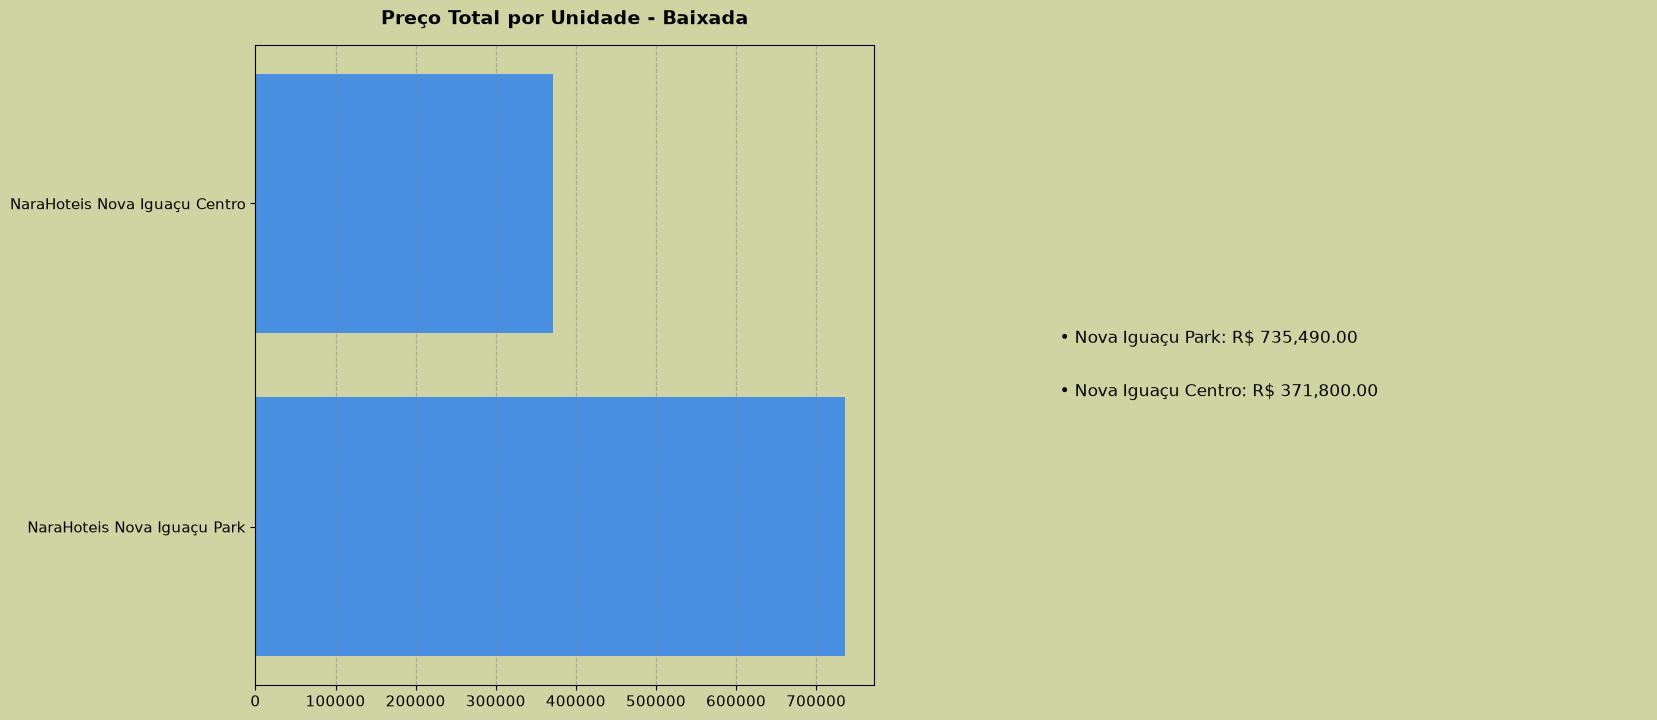

In [57]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

# Criando a figura com 1 linha e 2 colunas lado a lado
fig, (ax_grafico, ax_texto) = plt.subplots(1, 2, figsize=(16, 8), facecolor=cor_fundo_ppt)

# Definindo a cor de fundo dos eixos
ax_grafico.set_facecolor(cor_fundo_ppt)
ax_texto.set_facecolor(cor_fundo_ppt)

# --- Coluna 1: Gráfico de Barras Horizontais com graf_baixada ---
coluna_categorias = 'nome_unidade' # Ajuste para o nome real da sua coluna de unidades
coluna_valores = 'preco_total'     # Ajuste para a métrica de valor

bars = ax_grafico.barh(
    graf_baixada[coluna_categorias], 
    graf_baixada[coluna_valores], 
    color=minhas_cores[2]
)

ax_grafico.set_title("Preço Total por Unidade - Baixada", fontsize=14, color=cor_texto, fontweight="bold", pad=15)
ax_grafico.tick_params(colors=cor_texto, labelsize=11)
ax_grafico.grid(axis='x', linestyle='--', alpha=0.5, color='gray')

for spine in ax_grafico.spines.values():
    spine.set_color(cor_texto)

# --- Coluna 2: Bloco de Texto com os dados dinâmicos do graf_baixada ---
ax_texto.axis("off")

# Assumindo que a coluna de unidades se chama 'nome_unidade' e os valores estão em 'preco_total'
# Pegamos os valores filtrando pelo nome exato (ou por índice se preferir)
try:
    val_park = graf_baixada.loc[graf_baixada['nome_unidade'] == 'NaraHoteis Nova Iguaçu Park', 'preco_total'].values[0]
except IndexError:
    val_park = "Não encontrado"

try:
    val_centro = graf_baixada.loc[graf_baixada['nome_unidade'] == 'NaraHoteis Nova Iguaçu Centro', 'preco_total'].values[0]
except IndexError:
    val_centro = "Não encontrado"

texto_informacoes = (
    f"• Nova Iguaçu Park: R$ {val_park:,.2f}\n\n"
    f"• Nova Iguaçu Centro: R$ {val_centro:,.2f}"
)

ax_texto.text(
    0.05, 0.5,                  
    texto_informacoes,
    fontsize=12,
    color=cor_texto,
    va="center",
    ha="left",
    family="sans-serif",
    linespacing=1.6
)

fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.10, wspace=0.25)
plt.show()

Serra

In [58]:
serra = derivacao_regiao('Serra')

Variancia: 327388022.22 
STD: 18093.87
Faixa típica: 704512.80 até 740700.53


In [59]:
serra['df']

,id_unidade,nome_unidade,regiao,preco_total
8,9,NaraHoteis Friburgo,Serra,744480.0
7,8,NaraHoteis Teresópolis,Serra,723170.0
6,7,NaraHoteis Petrópolis,Serra,700170.0


## Extra:

In [60]:
r_fat_avaliac = np.corrcoef(array_faturamento, array_avaliac)

<Axes: >

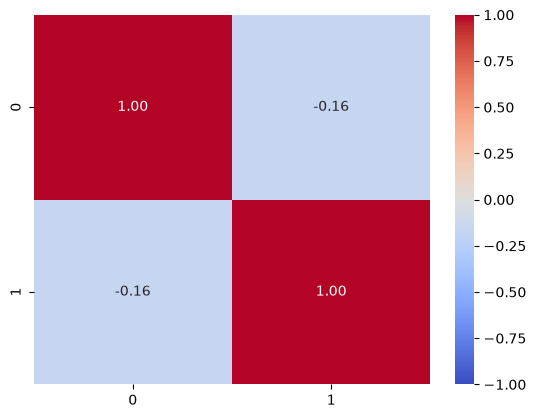

In [61]:
sns.heatmap(r_fat_avaliac, 
            annot=True,
            cmap='coolwarm', 
            vmin=-1,
            vmax=1,
            fmt='.2f'
            )

## Analise Semestral, vou transfromar em uma função para poder fazer mais analises

### Como eu tava com preguiça de usar o BI fiz minha propria função para uma analise entre os anos:

Eu poderia ter feito um que pega todos os meses do ano mas não tem tanto tempo então vou usar o BI

In [62]:
# Resumindo essa função pega um intervalo de tempo e compara os faturamentos entre elas
# Como essa função é só pra faciltiar não vou fazer tanta logica nela
def analise_faturamento_periodo(mes_dia_i, mes_dia_f, ano, ano2=None):
    if not len(mes_dia_i) == 5 or not len(mes_dia_f) == 5:
        print("Falha a data é inválida.")
        return None
    data_inicial = f'{ano + "-" + mes_dia_i}'
    data_final = f'{ano + "-" + mes_dia_f}'
    df_1 = df_no_cancel.loc[(df_no_cancel['data_checkin'] >= data_inicial) & (df_no_cancel['data_checkin'] <= data_final)]
    df_1= df_1.groupby(['id_unidade', 'nome_unidade'])['preco_total'].sum().reset_index(name=f'Faturamento{ano}' if ano2 else f'faturamento{mes_dia_i[:2]}')
    if ano2: # Se for uma analise entre dois anos ao invés de uma mensal
        data_inicial = f'{ano2 + "-" + mes_dia_i}'
        data_final = f'{ano2 + "-" + mes_dia_f}'
    elif not ano2:
        # Pega até o indice 1 do texto
        mes = int(mes_dia_i[:2]) + 1
        ano = int(ano)
        if mes > 12:
            mes = 1
            ano += 1
        # Retorna pra string 
        ano = str(ano)
        mes = str(mes)
        if len(mes) == 1:
            mes = '0' + mes
        mes_dia_i = f'{mes}{mes_dia_i[2:]}'
        if mes == '02':
            mes_dia_f = f'{mes}-{28}'
        else:
            mes_dia_f = f'{mes}{mes_dia_f[2:]}'
        data_inicial = f'{ano + "-" + mes_dia_i}'
        data_final = f'{ano}-{mes_dia_f}'
    df_2 = df_no_cancel.loc[(df_no_cancel['data_checkin'] >= data_inicial) & (df_no_cancel['data_checkin'] <= data_final)]
    df_2 = df_2.groupby(['id_unidade'])['preco_total'].sum().reset_index(name=f'faturamento{ano2}' if ano2 else f'faturamento{mes_dia_i[:2]}')
    df_analise = pd.merge(df_1, df_2, on='id_unidade', how='inner')
    # .iloc porque o nome varia então é mais fácil do que usar um f string
    df_analise['diferenca'] = df_analise.iloc[:, 3] - df_analise.iloc[:, 2]
    df_analise['status%'] = round(((df_analise['diferenca']) / df_analise.iloc[:, 2]) * 100, 2)
    return df_analise

In [71]:
def analise_unidade_historico(id_unidade):
    unidade = df_no_cancel.loc[df_no_cancel['id_unidade'] == id_unidade]
    ano_min = unidade['data_checkin'].min().year
    ano_max = unidade['data_checkin'].max().year
    if unidade['data_checkin'].max().month < 12: # Se o ultimo ano não terminou
        ano_max -= 1
    mes_dia = '01-01'
    mes_dia_f = '12-30'
    anos = list(range(ano_min, ano_max + 1)) # O +1 é só pra impedir o ultimo número de ficar de fora
    df_unidade = None # Declarando só para não ter erro no loop
    ano_anterior = ano_min
    for ano in anos:
        data = f'{ano}-{mes_dia}'
        data_f = f'{ano}-{mes_dia_f}'
        periodo = unidade.loc[(unidade['data_checkin'] >= data) & (unidade['data_checkin'] <= data_f)]
        if df_unidade is None:
            df_unidade = periodo.groupby(['id_unidade', 'nome_unidade'])['preco_total'].sum().reset_index(name=f'Faturamento{ano_min}')
        else:
            df_temp = periodo.groupby(['id_unidade'])['preco_total'].sum().reset_index(name=f'Faturamento{ano}')
            df_unidade = pd.merge(df_unidade, df_temp, on='id_unidade', how='inner')
            df_unidade[f'diferenca{ano}'] = df_unidade[f'Faturamento{ano}'] - df_unidade[f'Faturamento{ano_anterior}']
            df_unidade[f'status%{ano}'] = round(((df_unidade[f'diferenca{ano}']) / df_unidade[f'Faturamento{ano_anterior}']) * 100, 2)
            ano_anterior = ano
    return df_unidade

In [86]:
def analise_unidade_mensal(id_unidade, ano):
    unidade = df_no_cancel.loc[df_no_cancel['id_unidade'] == id_unidade]
    ultimo_mes = unidade['data_checkin'].max().month # Caso a analise seja no ultimo ano 
    ultimo_ano = unidade['data_checkin'].max().year # Caso a analise seja no ultimo ano 
    meses = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    df_unidade = None # Declarando só para não ter erro no loop
    mes_anterior = None
    for mes in meses:
        if mes == ultimo_mes and ano == ultimo_ano:
            break
        mes_formatado = '0'+str(mes) if mes < 10 else mes
        data_i = f'{ano}-{mes_formatado}-0{1}'
        data_f = f'{ano}-{mes_formatado}-{30 if mes != 2 else 28}'
        periodo = unidade.loc[(unidade['data_checkin'] >= data_i) & (unidade['data_checkin'] <= data_f)]
        if df_unidade is None:
            df_unidade = periodo.groupby(['id_unidade', 'nome_unidade'])['preco_total'].sum().reset_index(name=f'Faturamento{mes_formatado}')
            mes_anterior = mes_formatado
        else:
            df_temp = periodo.groupby(['id_unidade'])['preco_total'].sum().reset_index(name=f'Faturamento{mes_formatado}')
            df_unidade = pd.merge(df_unidade, df_temp, on='id_unidade', how='inner')
            df_unidade[f'diferenca{mes_formatado}'] = df_unidade[f'Faturamento{mes_formatado}'] - df_unidade[f'Faturamento{mes_anterior}']
            df_unidade[f'status%{mes_formatado}'] = round(((df_unidade[f'diferenca{mes_formatado}']) / df_unidade[f'Faturamento{mes_anterior}']) * 100, 2)
            mes_anterior = mes_formatado
    return df_unidade

In [ ]:
def grafico_temporal(df_historico):
    if df_historico is not None and not df_historico.empty:
        # Pega a primeira linha do resultado (já que é filtrado por id_unidade)
        dados_unidade = df_historico.iloc[0]
        # Identifica dinamicamente quais colunas começam com 'Faturamento'
        colunas_fat = [col for col in df_historico.columns if col.startswith('Faturamento')]
        # Extrai os anos limpos dos nomes das colunas (ex: 'Faturamento2023' vira '2023')
        anos = [col.replace('Faturamento', '') for col in colunas_fat]
        valores = dados_unidade[colunas_fat].values
        fig, ax = plt.subplots(figsize=(8, 5))
        # Cores tema
        fig.patch.set_facecolor('#D0D4A3FF')
        ax.set_facecolor('#D0D4A3FF')
        # Linha temporal
        ax.plot(anos, valores, marker='o', color='#030303', linewidth=2, markersize=8, label='Faturamento')
        # Títulos e rótulos personalizados
        nome_hotel = dados_unidade['nome_unidade']
        ax.set_title(f'Evolução do Faturamento Anual - {nome_hotel}', color='#030303', fontsize=12, fontweight='bold', pad=15)
        ax.set_xlabel('Ano', color='#030303', fontweight='bold')
        ax.set_ylabel('Faturamento Total (R$)', color='#030303', fontweight='bold')
        # Ajustando a cor dos eixos e bordas para o texto escuro
        ax.tick_params(colors='#030303', labelsize=10)
        for spine in ax.spines.values():
            spine.set_color('#030303') 
        # Pontilhado:
        ax.grid(True, linestyle='--', alpha=0.4, color='#030303')
        plt.tight_layout()
        plt.show()
    else:
        print("Nenhum dado encontrado para gerar o gráfico.")

In [92]:
def grafico_temporal_mensal(df_mensal, ano):
    if df_mensal is not None and not df_mensal.empty:
        dados_unidade = df_mensal.iloc[0]
        colunas_fat = [col for col in df_mensal.columns if col.startswith('Faturamento')]
        # Mapeamento numérico para nomes curtos dos meses
        meses_dict = {
            '01': 'Jan', '02': 'Fev', '03': 'Mar', '04': 'Abr', 
            '05': 'Mai', '06': 'Jun', '07': 'Jul', '08': 'Ago', 
            '09': 'Set', '10': 'Out', '11': 'Nov', '12': 'Dez'
        }
        # Extrai os meses limpos (ex: 'Faturamento01' vira '01', que vira 'Jan')
        meses_rotulos = []
        for col in colunas_fat:
            num_mes = col.replace('Faturamento', '')
            meses_rotulos.append(meses_dict.get(num_mes, num_mes))
        valores = dados_unidade[colunas_fat].values
        # Configuração do Gráfico com a identidade visual do NaraHoteis
        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor('#D0D4A3FF')
        ax.set_facecolor('#D0D4A3FF')
        # Linha temporal mensal
        ax.plot(meses_rotulos, valores, marker='o', color='#030303', linewidth=2, markersize=8, label='Faturamento Mensal')
        # Títulos e rótulos personalizados
        nome_hotel = dados_unidade['nome_unidade']
        ax.set_title(f'Evolução do Faturamento Mensal - {nome_hotel} ({ano})', color='#030303', fontsize=12, fontweight='bold', pad=15)
        ax.set_xlabel('Mês', color='#030303', fontweight='bold')
        ax.set_ylabel('Faturamento (R$)', color='#030303', fontweight='bold')
        # Ajustando a cor dos eixos e bordas para o texto escuro
        ax.tick_params(colors='#030303', labelsize=10)
        for spine in ax.spines.values():
            spine.set_color('#030303')    
        # Grelha pontilhada discreta
        ax.grid(True, linestyle='--', alpha=0.4, color='#030303')
        plt.tight_layout()
        plt.show()
    else:
        print("Nenhum dado encontrado para gerar o gráfico mensal.")

In [66]:
df_analise_semestre2526 = analise_faturamento_periodo('01-01', '06-30', '2025', '2026')
df_analise_semestre2526

,id_unidade,nome_unidade,Faturamento2025,faturamento2026,diferenca,status%
0,1,NaraHoteis Ipanema,100390.0,94750.0,-5640.0,-5.62
1,2,NaraHoteis Barra da Tijuca,90920.0,66060.0,-24860.0,-27.34
2,3,NaraHoteis Centro,121400.0,31920.0,-89480.0,-73.71
3,4,NaraHoteis Santa Teresa,94810.0,97380.0,2570.0,2.71
4,5,NaraHoteis Nova Iguaçu Centro,93180.0,96060.0,2880.0,3.09
5,6,NaraHoteis Nova Iguaçu Park,121600.0,73500.0,-48100.0,-39.56
6,7,NaraHoteis Petrópolis,72900.0,98790.0,25890.0,35.51
7,8,NaraHoteis Teresópolis,96920.0,91560.0,-5360.0,-5.53
8,9,NaraHoteis Friburgo,92670.0,108340.0,15670.0,16.91
9,10,NaraHoteis Paraty,93890.0,97340.0,3450.0,3.67


In [67]:
df_analise_mensal = analise_faturamento_periodo('01-01', '01-30', '2025')
df_analise_mensal

,id_unidade,nome_unidade,faturamento01,faturamento02,diferenca,status%
0,1,NaraHoteis Ipanema,7610.0,30420.0,22810.0,299.74
1,2,NaraHoteis Barra da Tijuca,4380.0,4980.0,600.0,13.70
2,3,NaraHoteis Centro,1740.0,3500.0,1760.0,101.15
3,4,NaraHoteis Santa Teresa,16410.0,14340.0,-2070.0,-12.61
4,5,NaraHoteis Nova Iguaçu Centro,6120.0,1400.0,-4720.0,-77.12
5,6,NaraHoteis Nova Iguaçu Park,21470.0,17350.0,-4120.0,-19.19
6,7,NaraHoteis Petrópolis,4260.0,4800.0,540.0,12.68
7,8,NaraHoteis Teresópolis,16120.0,19720.0,3600.0,22.33
8,9,NaraHoteis Friburgo,14690.0,7380.0,-7310.0,-49.76
9,10,NaraHoteis Paraty,14500.0,15140.0,640.0,4.41


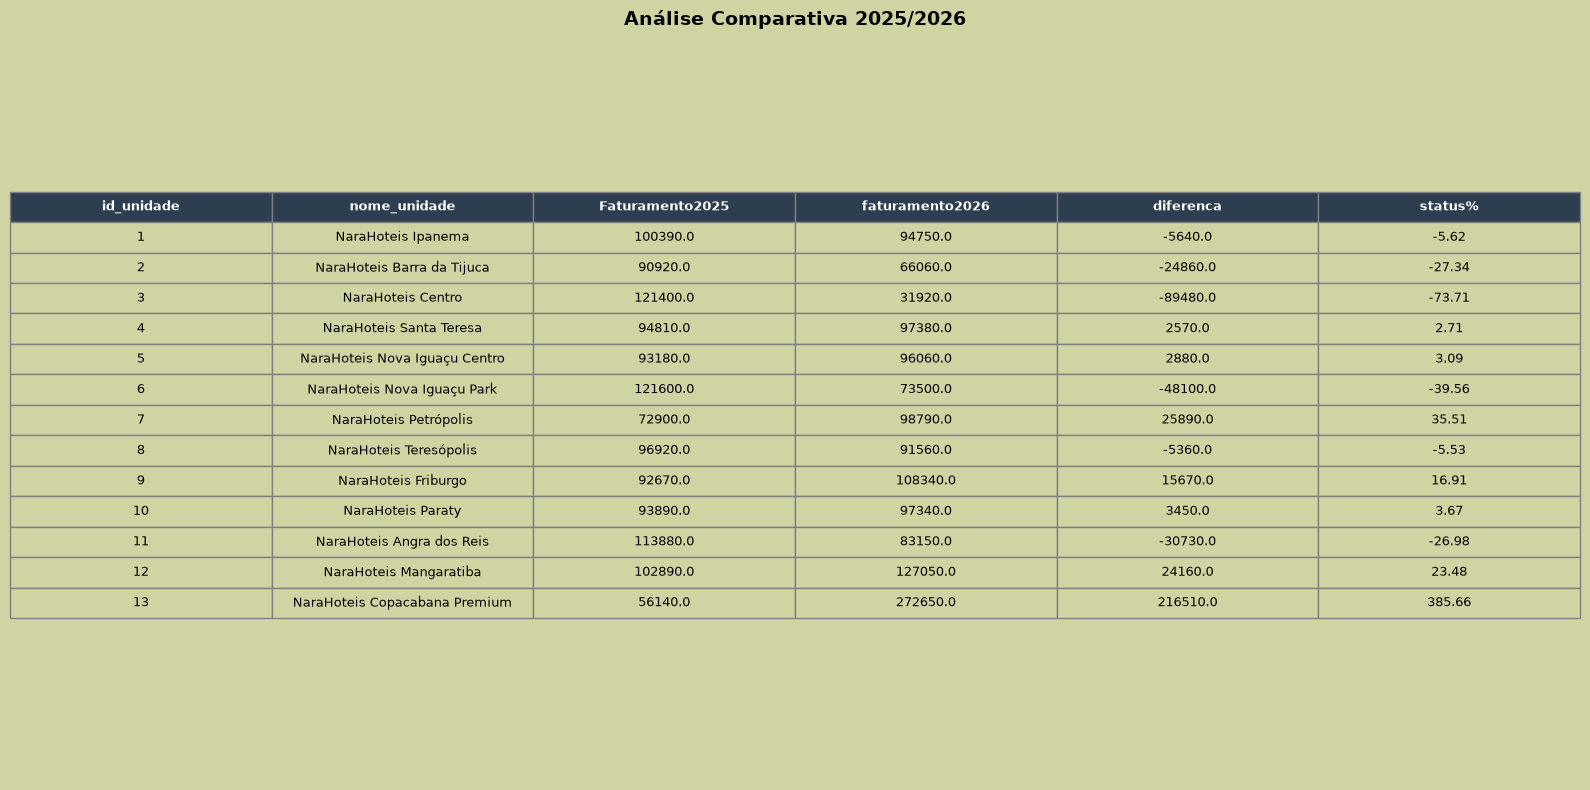

In [68]:
cor_fundo_ppt = "#D0D4A3FF"
cor_texto = "#030303"
minhas_cores = ['#2C3E50', '#34495E', '#4A90E2', '#5DADE2', '#3498DB', '#2980B9', '#1B4F72']

fig, ax_tabela = plt.subplots(1, 1, figsize=(16, 8), facecolor=cor_fundo_ppt)

# Definindo a cor de fundo dos eixos
ax_tabela.set_facecolor(cor_fundo_ppt)
ax_tabela.axis("off")

tabela = ax_tabela.table(
    cellText=df_analise_semestre2526.values,
    colLabels=df_analise_semestre2526.columns,
    loc='center',
    cellLoc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9.5)
tabela.scale(1, 1.5)

for key, cell in tabela.get_celld().items():
    cell.set_text_props(color=cor_texto)
    cell.set_edgecolor('gray')
    if key[0] == 0:  # Cabeçalho da tabela
        cell.set_facecolor(minhas_cores[0])
        cell.set_text_props(color='white', fontweight='bold')
    else:  # Células de dados
        cell.set_facecolor(cor_fundo_ppt)

# Diminuímos o pad para aproximar o título da tabela (ou você pode usar y=1.01 se quiser ajustar de forma exata)
ax_tabela.set_title("Análise Comparativa 2025/2026", fontsize=14, color=cor_texto, fontweight="bold", pad=-5)

# Ajuste final de layout
plt.tight_layout()
plt.show()

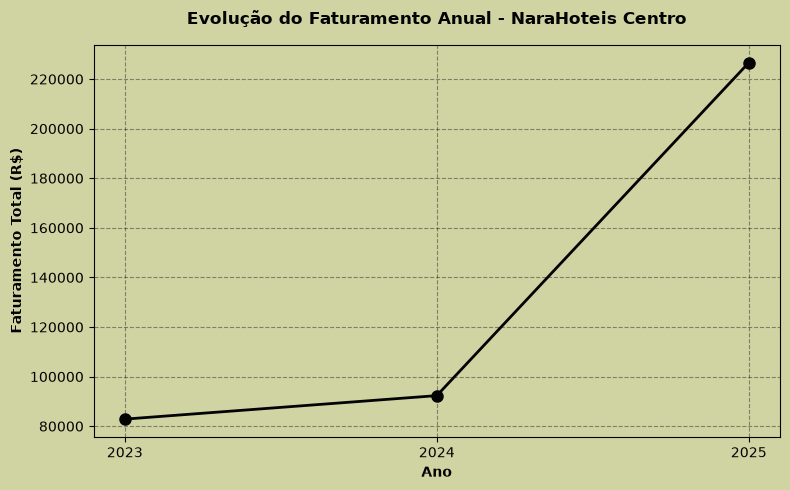

In [72]:
df_centro = analise_unidade_historico(3)
grafico_temporal(df_centro)

In [94]:
df_centro = analise_unidade_mensal(3, 2026)

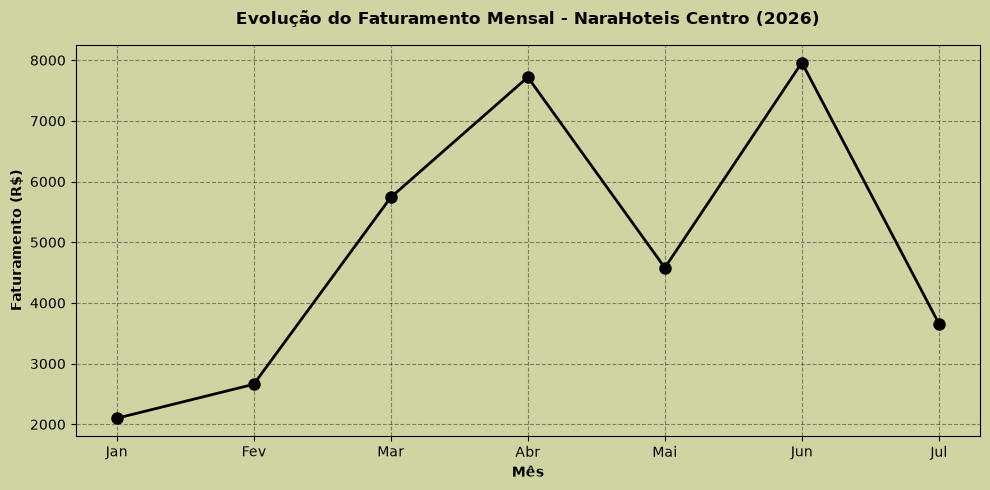

In [95]:
grafico_temporal_mensal(df_centro, 2026)

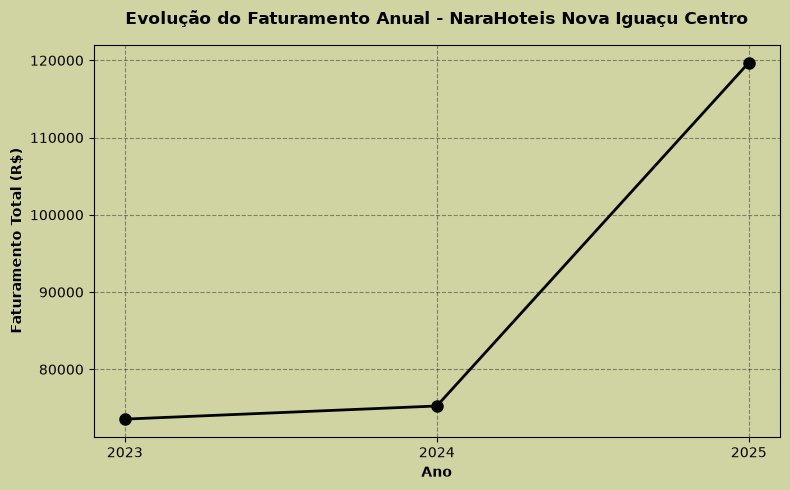

In [100]:
df_igacentro = analise_unidade_historico(5)
grafico_temporal(df_igacentro)

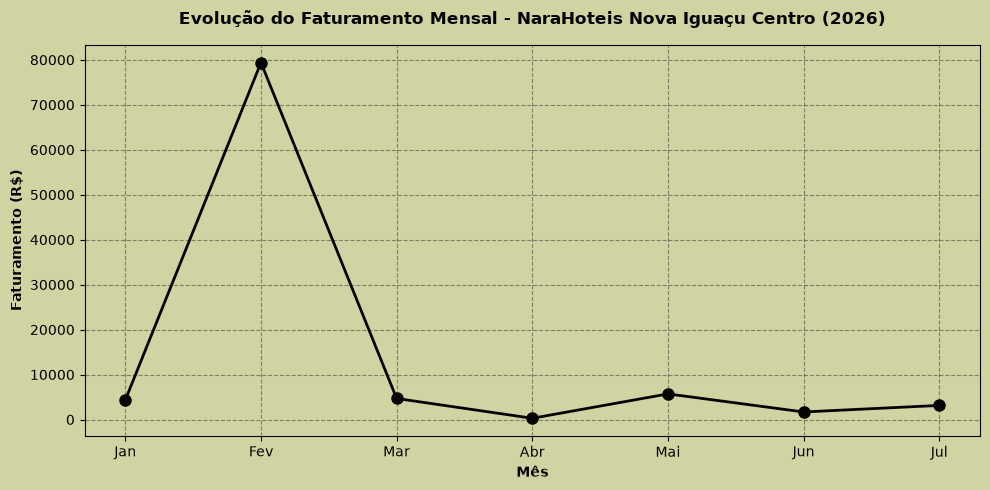

In [98]:
df_igacentro = analise_unidade_mensal(5, 2026)
grafico_temporal_mensal(df_igacentro, 2026)